# **Detecção e diagnóstico de anomalias em vibração de rolamentos (CWRU)**

ECM514 — Ciência de Dados · Projeto Desafio do 2º semestre.

Todo o código do projeto está neste notebook, no roteiro das aulas — *Clean Data*,
*Pre-Processing*, *Select Models*, *GridSearch*, *Melhor modelo*, *Predição* —, com
as etapas próprias do problema: validação física, detecção one-class e o teste de
generalização entre montagens. As figuras e tabelas do relatório
(`docs/relatorio/`) são gravadas por este notebook em `results/`.

O enunciado separa duas tarefas: *detectar que algo mudou* e *identificar o que
mudou*. As duas são tratadas e avaliadas separadamente.

## 0. Ambiente

In [1]:
import os, sys, subprocess, importlib.util, platform

REPO = "https://github.com/Nyfeu/Vibration_Analysis.git"
NO_COLAB = "google.colab" in sys.modules
if NO_COLAB:
    if not os.path.isdir("Vibration_Analysis"):
        subprocess.run(["git", "clone", "--depth", "1", REPO], check=True)
    os.chdir("Vibration_Analysis")
    # O Colab já traz NumPy, SciPy, pandas, scikit-learn, Matplotlib e PyTorch.
    # Instala só o que faltar, para não alterar as versões do ambiente.
    faltando = [pkg for mod, pkg in (("numpy", "numpy"), ("scipy", "scipy"), ("pandas", "pandas"),
                                     ("sklearn", "scikit-learn"), ("matplotlib", "matplotlib"))
                if importlib.util.find_spec(mod) is None]
    if faltando:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *faltando], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy, scipy, pandas, sklearn, matplotlib
versoes = {"python": platform.python_version(), "numpy": numpy.__version__, "scipy": scipy.__version__,
           "pandas": pandas.__version__, "scikit-learn": sklearn.__version__, "matplotlib": matplotlib.__version__}
if importlib.util.find_spec("torch"):
    import torch
    versoes["torch"] = torch.__version__
print("ambiente:", "Google Colab" if NO_COLAB else "local", "| pasta:", os.path.basename(os.getcwd()))
print(versoes)

ambiente: local | pasta: Vibration_Analysis
{'python': '3.12.3', 'numpy': '1.26.4', 'scipy': '1.11.4', 'pandas': '2.1.4', 'scikit-learn': '1.4.1.post1', 'matplotlib': '3.11.2', 'torch': '2.14.1+cpu'}


In [2]:
import random
import warnings

# Aviso inofensivo de instalações mistas do matplotlib (não ocorre no Colab).
warnings.filterwarnings("ignore", message="Unable to import Axes3D")
from dataclasses import dataclass
from math import ceil, cos, radians
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from scipy.io import loadmat
from scipy.signal import cheby1, decimate, hilbert, sosfiltfilt, welch
from sklearn.base import BaseEstimator, OutlierMixin
from sklearn.covariance import EmpiricalCovariance
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, OneClassSVM
from sklearn.tree import DecisionTreeClassifier, export_text

pd.set_option("display.width", 160)
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False})

In [3]:
# Caminhos relativos à raiz do repositório (a célula anterior já mudou para ela).
RAIZ = Path.cwd()
DIR_RAW = RAIZ / "data" / "raw"
MANIFESTO = DIR_RAW / "manifesto.csv"
AUDITORIA = RAIZ / "data" / "auditoria_smith2015.csv"
DIR_METRICS = RAIZ / "results" / "metrics"
DIR_FIGURES = RAIZ / "results" / "figures"
DIR_METRICS.mkdir(parents=True, exist_ok=True)
DIR_FIGURES.mkdir(parents=True, exist_ok=True)

# Semente única do projeto. Toda aleatoriedade (modelos, embaralhamento) parte
# dela, via `fixar_seeds`.
SEED = 42


# Taxa de amostragem de trabalho: a das gravações de falha do DE. Os normais
# (97-100) estão a 48 kHz e são decimados para ela (sec:decimacao-normais).
FS_HZ = 12_000


ORDEM_CLASSES = ["normal", "IR", "B", "OR"]


def fixar_seeds(seed: int = SEED) -> np.random.Generator:
    """Fixa as seeds do `random` e do `numpy` e devolve um Generator com a mesma."""
    random.seed(seed)
    np.random.seed(seed)
    return np.random.default_rng(seed)


NOMES_CLASSE = {"normal": "Normal", "IR": "Pista interna", "B": "Esfera", "OR": "Pista externa"}

rng = fixar_seeds(SEED)
print("SEED =", SEED)

SEED = 42


# **Clean Data**

Os 56 arquivos `.mat` do CWRU estão versionados em `data/raw/`, com o SHA-256 de
cada um no manifesto. Nenhuma gravação é excluída por qualidade; as que não
mostram o defeito ficam **com ressalva** (auditoria de Smith & Randall, 2015, em
`docs/arquivos_excluidos.md`). Três problemas de dados são tratados na leitura:

1. os normais (97–100) estão a **48 kHz**, não 12 kHz → decimação por 4;
2. `99.mat` contém também as variáveis de `98.mat` → leitura pelo nome gravado no manifesto;
3. `98.mat` e `99.mat` não têm a rotação medida → rotação nominal.

In [4]:
# Posição do defeito em pista externa, em horas, com a zona de carga em 6 h
# (Smith & Randall, 2015, p. 104). @6 é a única posição com os três diâmetros
# (0.007", 0.014", 0.021") e deixa as classes equilibradas (12 IR, 12 B, 12 OR).
# @3 (ortogonal) e @12 (oposta) mudam a amplitude e a modulação do sinal, por isso
# ficam fora do experimento principal: servem para testar se um modelo treinado
# em @6 generaliza para outra posição. Ver docs/arquivos_excluidos.md (C5).
POSICAO_OR_PRINCIPAL = "6"


POSICOES_OR_GENERALIZACAO = ("3", "12")


CONJUNTOS = ("principal", "generalizacao")


def ler_manifesto() -> pd.DataFrame:
    """Manifesto completo (56 registros), com a coluna `rpm` já resolvida.

    `rpm` é a rotação medida no arquivo (variável XnnnRPM) ou, se o arquivo não
    a traz (98 e 99), a nominal da carga (data/raw/README.md, item 3).
    """
    # dtype=str em posicao_or_h: sem isso o pandas lê "6" como 6.0 e o filtro falha.
    m = pd.read_csv(MANIFESTO, dtype={"posicao_or_h": str, "diametro_pol": str})
    m["rpm"] = m["rpm_arquivo"].fillna(m["rpm_nominal"]).astype(float)
    return m


def catalogo(conjunto: str = "principal") -> pd.DataFrame:
    """Registros de um conjunto do experimento, lidos de data/raw/manifesto.csv.

    - ``"principal"``: normais, IR, B e OR na posição ``POSICAO_OR_PRINCIPAL``
      (40 registros).
    - ``"generalizacao"``: só OR nas posições ``POSICOES_OR_GENERALIZACAO``
      (16 registros).

    Nenhum registro é excluído por qualidade; as ressalvas da auditoria estão em
    docs/arquivos_excluidos.md.
    """
    if conjunto not in CONJUNTOS:
        raise ValueError(f"conjunto deve ser um de {CONJUNTOS}, não {conjunto!r}")
    m = ler_manifesto()
    eh_or = m["classe"] == "OR"
    if conjunto == "principal":
        sel = ~eh_or | (m["posicao_or_h"] == POSICAO_OR_PRINCIPAL)
    else:
        sel = eh_or & m["posicao_or_h"].isin(POSICOES_OR_GENERALIZACAO)
    return m[sel].reset_index(drop=True)

In [5]:
manifesto = ler_manifesto()
print("arquivos no manifesto:", len(manifesto))
display(manifesto.groupby(["classe", "fs_hz"]).size().rename("arquivos").to_frame())
principal = catalogo("principal")
print("conjunto principal:", len(principal), "gravações | generalização (OR @3/@12):", len(catalogo("generalizacao")))

arquivos no manifesto: 56


,,arquivos
classe,fs_hz,
B,12000,12
IR,12000,12
OR,12000,28
normal,48000,4


conjunto principal: 40 gravações | generalização (OR @3/@12): 16


1. **Quais dados foram identificados como problemáticos e quantos registros foram excluídos?**

In [6]:
def ler_auditoria() -> pd.DataFrame:
    """Diagnóstico do DE por Smith & Randall (2015, Tab. B2), por registro."""
    return pd.read_csv(AUDITORIA, comment="#", dtype=str).assign(
        registro=lambda d: d["registro"].astype(int)
    )

In [7]:
aud = ler_auditoria().merge(manifesto[["id", "classe"]], left_on="registro", right_on="id")
aud = aud[aud["registro"].isin(principal["id"])]
display(pd.crosstab(aud["classe"], aud["grupo"]).rename(
    columns={"Y": "Y (diagnosticável)", "P": "P (parcial)", "N": "N (não)"}))
print("Excluídos: 0. Mantidos com ressalva: os grupos P e N (Smith & Randall, 2015, Tab. B2) e os normais a 48 kHz.")

grupo,N (não),P (parcial),Y (diagnosticável)
classe,,,
B,5,4,3
IR,0,0,12
OR,1,2,9


Excluídos: 0. Mantidos com ressalva: os grupos P e N (Smith & Randall, 2015, Tab. B2) e os normais a 48 kHz.


### Leitura, decimação e banda comum

A variável do DE é lida pelo nome do manifesto. Os normais são decimados de 48
para 12 kHz, e **todas** as gravações passam pelo mesmo passa-baixas de 4,8 kHz:
sem isso, a faixa 4,8–6 kHz (com resíduo de *aliasing* nos normais) diferenciaria
normal de falha por artefato.

In [8]:
# Banda comum de análise: 0 a 4,8 kHz em TODAS as gravações. 4,8 kHz é o corte
# do filtro anti-aliasing do scipy.signal.decimate (0,8 x Nyquist de 12 kHz).
# Aplicado a todas as gravações depois da decimação (ver carregar_sinal). Sem isso, a faixa de 4,8-6 kHz ficaria atenuada
# só nos normais, e um modelo poderia separar as classes pelo pré-processamento
# (sec:decimacao-normais; results/figures/espectro_normal_decimado_vs_falhas.png).
CORTE_BANDA_COMUM_HZ = 4_800.0


_SOS_BANDA_COMUM = cheby1(8, 0.05, CORTE_BANDA_COMUM_HZ / (FS_HZ / 2), output="sos")


def carregar_sinal(registro: pd.Series, banda_comum: bool = True) -> np.ndarray:
    """Sinal do DE de um registro do manifesto, sempre a FS_HZ (12 kHz).

    A variável é lida pelo nome gravado no manifesto (`variavel_de`, ex.:
    X099_DE_time), nunca pela "primeira chave que termina em DE_time": o 99.mat
    traz também as variáveis do 98.

    Registros a 48 kHz (os normais) são decimados por 4 com
    `scipy.signal.decimate` padrão: IIR Chebyshev I de ordem 8, corte em
    0,8 x 6 kHz = 4,8 kHz, aplicado nos dois sentidos (fase zero, preserva a
    forma dos impulsos). Ver sec:decimacao no relatório.

    Com `banda_comum=True` (padrão), todo registro passa ainda, já a 12 kHz,
    pelo mesmo passa-baixas (Chebyshev I, ordem 8, 4,8 kHz, fase zero). Nas
    falhas ele faz o papel do filtro da decimação; nos normais, remove o resto
    de aliasing que o filtro do `decimate` deixa em 4,8-6 kHz (a 48 kHz há
    energia de 6 a 24 kHz que ele não atenua o bastante). Assim normais e falhas
    chegam ao modelo com a mesma banda. `False` devolve o sinal só decimado, ou
    como gravado (usado na figura de comparação).
    """
    var = registro["variavel_de"]
    mat = loadmat(DIR_RAW / registro["arquivo"], variable_names=[var])
    if var not in mat:
        raise KeyError(f"{registro['arquivo']} não tem a variável {var}")
    x = np.asarray(mat[var], dtype=float).ravel()

    fs = int(registro["fs_hz"])
    if fs != FS_HZ:
        q, resto = divmod(fs, FS_HZ)
        if resto:
            raise ValueError(f"{registro['arquivo']}: {fs} Hz não é múltiplo de {FS_HZ} Hz")
        x = decimate(x, q)
    if banda_comum:
        x = sosfiltfilt(_SOS_BANDA_COMUM, x)
    return x

In [9]:
# Corte do filtro de scipy.signal.decimate (q = 4): 0,8 x 6 kHz.
CORTE_HZ = 4800.0


NYQUIST_HZ = FS_HZ / 2


# Paleta categórica de referência (validada para daltonismo); cinza = referência.
COR_NORMAL = "#8a8a85"


CORES_FALHA = {"IR": "#eb6834", "B": "#1baf7a", "OR": "#2a78d6"}


def psd(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """PSD de Welch com segmentos de 4096 amostras (a janela de análise)."""
    return welch(x, fs=FS_HZ, nperseg=4096)


def fracao_na_banda(f: np.ndarray, p: np.ndarray) -> float:
    banda = (f >= CORTE_HZ) & (f <= NYQUIST_HZ)
    return float(p[banda].sum() / p.sum())


def energia_e_figura() -> None:
    cat = catalogo("principal")
    linhas, espectros = [], {}
    for _, reg in cat.iterrows():
        f, p = psd(carregar_sinal(reg, banda_comum=False))
        f2, p2 = psd(carregar_sinal(reg))
        espectros[reg["id"]] = (f, p)
        linhas.append(
            {
                "registro": reg["id"],
                "classe": reg["classe"],
                "diametro_pol": reg["diametro_pol"],
                "carga_hp": reg["carga_hp"],
                "fracao_antes": fracao_na_banda(f, p),
                "fracao_depois": fracao_na_banda(f2, p2),
            }
        )
    energia = pd.DataFrame(linhas)
    energia.to_csv(DIR_METRICS / "energia_banda_4k8_6k.csv", index=False)
    (
        energia.groupby("classe")[["fracao_antes", "fracao_depois"]]
        .agg(["min", "max"])
        .loc[["normal", "IR", "B", "OR"]]
        .to_csv(DIR_METRICS / "energia_banda_4k8_6k_por_classe.csv")
    )

    # Mesma carga (0 HP) e menor diâmetro (0.007"): a comparação mais próxima
    # do normal 97.
    ref = cat[(cat["classe"] == "normal") & (cat["carga_hp"] == 0)]["id"].item()
    falhas = {
        c: cat[(cat["classe"] == c) & (cat["carga_hp"] == 0) & (cat["diametro_pol"] == "0.007")][
            "id"
        ].item()
        for c in ("IR", "B", "OR")
    }

    plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False})
    fig, eixos = plt.subplots(1, 3, figsize=(7.2, 2.6), sharey=True, constrained_layout=True)
    fn, pn = espectros[ref]
    for ax, (classe, rid) in zip(eixos, falhas.items()):
        f, p = espectros[rid]
        ax.axvspan(CORTE_HZ / 1e3, NYQUIST_HZ / 1e3, color="#e8e7e2", lw=0)
        ax.plot(fn / 1e3, 10 * np.log10(pn), color=COR_NORMAL, lw=1.0, label=f"Normal ({ref}, decimado)")
        ax.plot(f / 1e3, 10 * np.log10(p), color=CORES_FALHA[classe], lw=1.0, label=f"{NOMES_CLASSE[classe]} ({rid})")
        ax.set_title(f"{NOMES_CLASSE[classe]} ({rid}) × normal ({ref})", fontsize=9)
        ax.set_xlim(0, NYQUIST_HZ / 1e3)
        ax.set_xlabel("Frequência (kHz)")
        ax.grid(axis="y", color="#e8e7e2", lw=0.6)
        ax.legend(loc="lower left", fontsize=7, frameon=False)
    eixos[0].set_ylabel("PSD (dB re 1 unidade²/Hz)")
    eixos[0].text(5.4, eixos[0].get_ylim()[1], "4,8–6 kHz", ha="center", va="top", fontsize=7, color="#5f5e5a")
    fig.savefig(DIR_FIGURES / "espectro_normal_decimado_vs_falhas.png", dpi=200)

fracao_antes          fracao_depois         
                min      max           min      max
classe                                             
normal      0.00132  0.00934       0.00025  0.00051
IR          0.00058  0.00328       0.00005  0.00083
B           0.00045  0.02217       0.00002  0.00044
OR          0.00102  0.05465       0.00004  0.00019

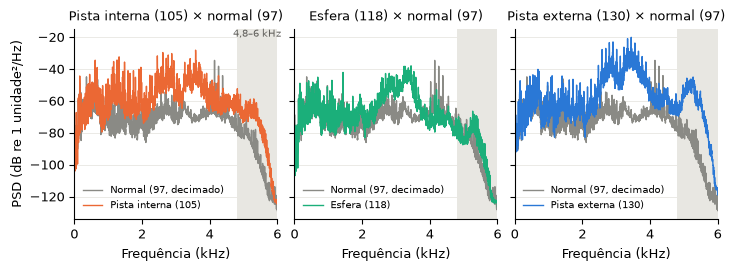

In [10]:
energia_e_figura()
pd.read_csv(DIR_METRICS / "energia_banda_4k8_6k_por_classe.csv", header=[0, 1], index_col=0).round(5)

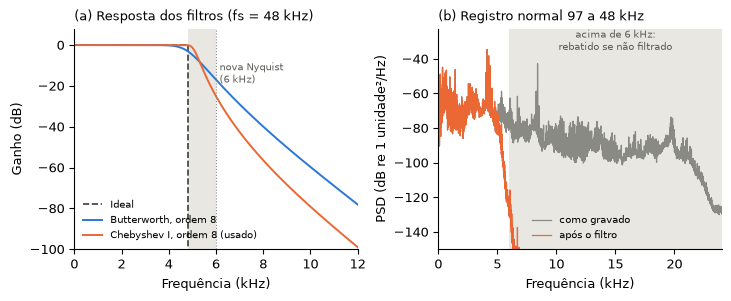

In [11]:
from matplotlib.ticker import FuncFormatter
from scipy.signal import butter, sosfreqz


# Vírgula decimal nos eixos das figuras.
VIRGULA = FuncFormatter(lambda v, _: f"{v:g}".replace(".", ","))


def figura_filtros_antialiasing(rid: int = 97) -> None:
    """(a) Resposta em magnitude do passa-baixas ideal, de um Butterworth e do
    Chebyshev I que o `decimate` usa, todos com corte em 4,8 kHz e a taxa
    original de 48 kHz. (b) Espectro do normal 97 como gravado (48 kHz) e depois
    do filtro: o que fica acima de 6 kHz seria rebatido pela subamostragem."""
    fs0, q = 48_000, 4
    nyq_nova = fs0 / q / 2
    filtros = {
        "Butterworth, ordem 8": butter(8, CORTE_HZ, fs=fs0, output="sos"),
        "Chebyshev I, ordem 8 (usado)": cheby1(8, 0.05, 0.8 / q, output="sos"),
    }
    cores = {"Butterworth, ordem 8": "#2a78d6", "Chebyshev I, ordem 8 (usado)": "#eb6834"}

    reg = ler_manifesto().set_index("id").loc[rid]
    x = np.asarray(loadmat(DIR_RAW / reg["arquivo"], variable_names=[reg["variavel_de"]])[reg["variavel_de"]], float).ravel()
    f0, p0 = welch(x, fs=fs0, nperseg=4 * 4096)
    f1, p1 = welch(sosfiltfilt(filtros["Chebyshev I, ordem 8 (usado)"], x), fs=fs0, nperseg=4 * 4096)

    plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False})
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.2, 2.9), constrained_layout=True)
    a1.plot([0, CORTE_HZ / 1e3, CORTE_HZ / 1e3, 12], [0, 0, -120, -120], color="#3d3d3a", lw=1.2, ls="--", label="Ideal")
    for nome, sos in filtros.items():
        w, h = sosfreqz(sos, worN=4096, fs=fs0)
        a1.plot(w / 1e3, 20 * np.log10(np.maximum(np.abs(h), 1e-12)), color=cores[nome], lw=1.4, label=nome)
    a1.axvspan(CORTE_HZ / 1e3, nyq_nova / 1e3, color="#e8e7e2", lw=0)
    a1.axvline(nyq_nova / 1e3, color="#8a8a85", lw=0.8, ls=":")
    a1.text(nyq_nova / 1e3 + 0.15, -8, "nova Nyquist\n(6 kHz)", fontsize=7, color="#5f5e5a", va="top")
    a1.set_xlim(0, 12)
    a1.set_ylim(-100, 8)
    a1.set_xlabel("Frequência (kHz)")
    a1.set_ylabel("Ganho (dB)")
    a1.set_title("(a) Resposta dos filtros (fs = 48 kHz)", fontsize=9, loc="left")
    a1.legend(fontsize=7, frameon=False, loc="lower left")

    a2.axvspan(nyq_nova / 1e3, fs0 / 2e3, color="#e8e7e2", lw=0)
    a2.plot(f0 / 1e3, 10 * np.log10(p0), color=COR_NORMAL, lw=0.9, label="como gravado")
    a2.plot(f1 / 1e3, 10 * np.log10(np.maximum(p1, 1e-30)), color="#eb6834", lw=0.9, label="após o filtro")
    a2.text(15, a2.get_ylim()[1], "acima de 6 kHz:\nrebatido se não filtrado", fontsize=7, color="#5f5e5a", ha="center", va="top")
    a2.set_xlim(0, fs0 / 2e3)
    a2.set_ylim(-150, None)
    a2.set_xlabel("Frequência (kHz)")
    a2.set_ylabel("PSD (dB re 1 unidade²/Hz)")
    a2.set_title(f"(b) Registro normal {rid} a 48 kHz", fontsize=9, loc="left")
    a2.legend(fontsize=7, frameon=False, loc="lower left", bbox_to_anchor=(0.3, 0.0))
    fig.savefig(DIR_FIGURES / "filtro_antialiasing.png", dpi=200)


with plt.rc_context():  # não altera a fonte das figuras seguintes
    figura_filtros_antialiasing()

# **Pre-Processing**

## Train, Test split

O split **não** é aleatório: janelas da mesma gravação são quase idênticas, e
espalhá-las entre treino e teste mede memorização da gravação. Treino com 0, 1 e
2 HP; teste com 3 HP. Cada gravação tem uma única carga, então nenhuma gravação
fica nos dois lados (verificado em `split_por_carga`).

A janela é derivada da física: 3 períodos da gaiola (FTF) na menor rotação do
conjunto, arredondado para potência de 2 → 4096 amostras (≈ 3,9 períodos). A FTF vem da geometria
do rolamento SKF 6205.

In [12]:
@dataclass(frozen=True)
class GeometriaRolamento:
    """Geometria do rolamento. Comprimentos na mesma unidade (aqui, polegadas)."""

    n_esferas: int
    diametro_esfera: float  # d
    diametro_primitivo: float  # D
    angulo_contato_graus: float = 0.0  # phi


# Fontes:
#  - d e D: CWRU Bearing Data Center, página "Bearing Specifications"
#    (drive end: ball diameter 0.3126 in, pitch diameter 1.537 in).
#  - n = 9: Smith & Randall (2015), p. 109. Essa página do CWRU não informa n.
SKF_6205_DE = GeometriaRolamento(
    n_esferas=9, diametro_esfera=0.3126, diametro_primitivo=1.537
)


@dataclass(frozen=True)
class FrequenciasCaracteristicas:
    """Frequências em Hz."""

    bpfo: float  # pista externa
    bpfi: float  # pista interna
    bsf: float  # esfera (ball spin frequency), convenção de Smith & Randall
    ftf: float  # gaiola

    @property
    def bsf_2x(self) -> float:
        """2 x BSF: o "Rolling Element" da página do CWRU (4,7135 x f_r).

        Não é a frequência de referência do projeto (ver BSF acima). Fisicamente,
        a esfera com defeito bate nas duas pistas a cada giro, e por isso os
        harmônicos pares de BSF costumam dominar o espectro de envelope (Smith &
        Randall, 2015, Tab. 1, p. 103). Use este valor para procurar esse
        harmônico, sem trocar a convenção.
        """
        return 2.0 * self.bsf


def frequencias_caracteristicas(
    rpm: float, geometria: GeometriaRolamento = SKF_6205_DE
) -> FrequenciasCaracteristicas:
    """Calcula BPFO, BPFI, BSF e FTF (em Hz) a partir da rotação em rpm.

    Prefira a rotação medida em cada arquivo .mat (variável XnnnRPM) à nominal,
    porque a rotação real cai com a carga. 98.mat e 99.mat não trazem essa
    variável: neles use a nominal (1772 e 1750 rpm; ver data/raw/README.md).
    """
    if rpm <= 0:
        raise ValueError(f"rpm deve ser positivo, recebido {rpm!r}")

    f_r = rpm / 60.0
    n = geometria.n_esferas
    d = geometria.diametro_esfera
    big_d = geometria.diametro_primitivo
    razao = (d / big_d) * cos(radians(geometria.angulo_contato_graus))

    return FrequenciasCaracteristicas(
        bpfo=n * f_r / 2.0 * (1.0 - razao),
        bpfi=n * f_r / 2.0 * (1.0 + razao),
        bsf=big_d * f_r / (2.0 * d) * (1.0 - razao**2),
        ftf=f_r / 2.0 * (1.0 - razao),
    )


def banda_tolerancia(freq_hz: float, tol: float = 0.02) -> tuple[float, float]:
    """Janela de busca em torno de uma frequência teórica (padrão: +-2%).

    Os 2% vêm do escorregamento típico de 1% a 2% (Smith & Randall, 2015, p. 102).
    """
    return freq_hz * (1.0 - tol), freq_hz * (1.0 + tol)

In [13]:
# Número de períodos da gaiola (FTF) que cada janela deve conter. É a
# modulação mais lenta das assinaturas de defeito (esfera: bandas laterais
# espaçadas de FTF; relatório, tab:assinaturas). Com 3 períodos, a resolução do
# espectro, fs/N, fica em no máximo FTF/3, o que separa essas bandas laterais
# dos picos vizinhos.
N_PERIODOS_FTF = 3


def tamanho_janela(
    rpm_min: float, fs: int = FS_HZ, n_periodos_ftf: int = N_PERIODOS_FTF
) -> int:
    """Número de amostras por janela, derivado da rotação e da taxa de amostragem.

    N_min = n_periodos_ftf * fs / FTF(rpm_min), arredondado para a potência de 2
    seguinte (FFT). Usa a menor rotação do conjunto, que dá a FTF mais baixa e
    portanto o período mais longo.

    Com os dados do projeto (rpm_min = 1718, registro 261; fs = 12 kHz):
        f_r = 1718 / 60          = 28,63 Hz
        FTF = 0,3983 * f_r       = 11,40 Hz
        N_min = 3 * 12000 / 11,40 = 3157 amostras
        N = 4096 amostras = 0,341 s
          = 9,8 revoluções do eixo a 1718 rpm (10,2 a 1797 rpm)
          = 3,9 períodos da gaiola; resolução fs/N = 2,93 Hz
    """
    ftf = frequencias_caracteristicas(rpm_min, SKF_6205_DE).ftf
    n_min = ceil(n_periodos_ftf * fs / ftf)
    return 1 << (n_min - 1).bit_length()


def segmentar(x: np.ndarray, tamanho: int, passo: int) -> np.ndarray:
    """Janelas (n_janelas, tamanho) de um sinal 1D; a sobra final é descartada."""
    if len(x) < tamanho:
        return np.empty((0, tamanho))
    return np.lib.stride_tricks.sliding_window_view(x, tamanho)[::passo].copy()


def montar_janelas(
    conjunto: str = "principal",
    tamanho: int | None = None,
    passo: int | None = None,
) -> tuple[np.ndarray, pd.DataFrame]:
    """Janelas de todos os registros de um conjunto e os metadados de cada uma.

    `tamanho` padrão: `tamanho_janela` com a menor rotação do manifesto inteiro,
    para que o conjunto principal e o de generalização usem a mesma janela.
    `passo` padrão: metade da janela (sobreposição de 50%). A sobreposição não
    cria vazamento porque o split é por registro, nunca por janela.

    Devolve (X, meta): a linha i de `meta` descreve a janela X[i]
    (registro, classe, diâmetro, posição OR, carga, rpm, índice da janela).
    """
    if tamanho is None:
        tamanho = tamanho_janela(ler_manifesto()["rpm"].min())
    if passo is None:
        passo = tamanho // 2

    cat = catalogo(conjunto)
    blocos, metas = [], []
    for _, reg in cat.iterrows():
        w = segmentar(carregar_sinal(reg), tamanho, passo)
        blocos.append(w)
        metas.append(
            pd.DataFrame(
                {
                    "registro": reg["id"],
                    "classe": reg["classe"],
                    "diametro_pol": reg["diametro_pol"],
                    "posicao_or_h": reg["posicao_or_h"],
                    "carga_hp": reg["carga_hp"],
                    "rpm": reg["rpm"],
                    "janela": np.arange(len(w)),
                }
            )
        )
    return np.vstack(blocos), pd.concat(metas, ignore_index=True)

In [14]:
CARGAS_TREINO = (0, 1, 2)


CARGAS_TESTE = (3,)


def verificar_sem_vazamento(meta_treino: pd.DataFrame, meta_teste: pd.DataFrame) -> None:
    """Falha se algum registro tiver janelas no treino e no teste ao mesmo tempo."""
    comuns = set(meta_treino["registro"]) & set(meta_teste["registro"])
    if comuns:
        raise AssertionError(f"registros em treino e teste: {sorted(comuns)}")


def split_por_carga(
    meta: pd.DataFrame,
    cargas_treino: tuple[int, ...] = CARGAS_TREINO,
    cargas_teste: tuple[int, ...] = CARGAS_TESTE,
) -> tuple[np.ndarray, np.ndarray]:
    """Máscaras booleanas (treino, teste) sobre as janelas de `meta`.

    O split é por condição de carga, logo por registro: cada registro tem uma
    única carga, e todas as suas janelas caem do mesmo lado. A pergunta é se o
    modelo generaliza para uma carga não vista.
    """
    if set(cargas_treino) & set(cargas_teste):
        raise ValueError("cargas de treino e teste se sobrepõem")
    treino = meta["carga_hp"].isin(cargas_treino).to_numpy()
    teste = meta["carga_hp"].isin(cargas_teste).to_numpy()
    verificar_sem_vazamento(meta[treino], meta[teste])
    return treino, teste


def contagem_janelas(meta: pd.DataFrame) -> pd.DataFrame:
    """Janelas por classe (linhas) e carga (colunas), com totais."""
    t = pd.crosstab(meta["classe"], meta["carga_hp"], margins=True, margins_name="total")
    ordem = [c for c in ORDEM_CLASSES if c in t.index] + ["total"]
    return t.loc[ordem]


def contagens() -> None:
    for conjunto in ("principal", "generalizacao"):
        _, meta = montar_janelas(conjunto)
        contagem_janelas(meta).to_csv(DIR_METRICS / f"contagem_janelas_{conjunto}.csv")

In [15]:
print("tamanho da janela:", tamanho_janela(manifesto["rpm"].min()), "amostras")
X, meta = montar_janelas("principal")
Xg, meta_g = montar_janelas("generalizacao")
treino, teste = split_por_carga(meta)
contagens()
contagem_janelas(meta)

tamanho da janela: 4096 amostras


carga_hp,0,1,2,3,total
classe,,,,,
normal,28,58,58,58,202
IR,174,174,174,175,697
B,174,174,174,174,696
OR,174,174,174,174,696
total,550,580,580,581,2291


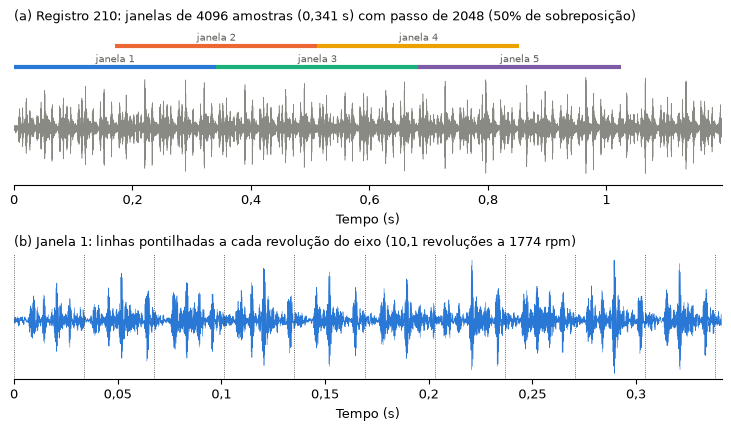

In [16]:
def figura_segmentacao(rid: int = 210, n_mostrar: int = 5) -> None:
    """Primeiras janelas de uma gravação: 4096 amostras cada, passo de 2048
    (50% de sobreposição). Abaixo, uma janela com as revoluções do eixo."""
    reg = ler_manifesto().set_index("id").loc[rid].copy()
    reg["id"] = rid
    x = carregar_sinal(reg)
    n = tamanho_janela(ler_manifesto()["rpm"].min())
    passo = n // 2
    t = np.arange(len(x)) / FS_HZ
    fim = (n_mostrar - 1) * passo + n

    plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False})
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(7.2, 4.2), constrained_layout=True, height_ratios=[1.25, 1])
    a1.plot(t[: fim + passo], x[: fim + passo], color="#8a8a85", lw=0.4)
    topo = np.abs(x[: fim + passo]).max()
    cores = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#7d5ba6"]
    for k in range(n_mostrar):
        ini = k * passo
        y = topo * (1.2 + 0.42 * (k % 2))
        a1.plot([t[ini], t[ini + n - 1]], [y, y], color=cores[k], lw=3, solid_capstyle="butt")
        a1.text((t[ini] + t[ini + n - 1]) / 2, y + topo * 0.05, f"janela {k + 1}", ha="center", va="bottom", fontsize=7, color="#5f5e5a")
    a1.set_ylim(-topo * 1.1, topo * 1.95)
    a1.set_xlim(0, t[fim + passo - 1])
    a1.set_yticks([])
    a1.spines["left"].set_visible(False)
    a1.set_xlabel("Tempo (s)")
    a1.set_title(f"(a) Registro {rid}: janelas de {n} amostras ({n / FS_HZ:.3f} s) com passo de {passo} (50% de sobreposição)".replace(".", ","), fontsize=9, loc="left")

    j = x[:n]
    tj = np.arange(n) / FS_HZ
    a2.plot(tj, j, color=cores[0], lw=0.4)
    f_r = reg["rpm"] / 60
    for k in range(int(n / FS_HZ * f_r) + 1):
        a2.axvline(k / f_r, color="#3d3d3a", lw=0.6, ls=":")
    a2.set_xlim(0, n / FS_HZ)
    a2.set_yticks([])
    a2.spines["left"].set_visible(False)
    a2.set_xlabel("Tempo (s)")
    voltas = n / FS_HZ * f_r
    a2.set_title(f"(b) Janela 1: linhas pontilhadas a cada revolução do eixo ({voltas:.1f} revoluções a {reg['rpm']:.0f} rpm)".replace(".", ","), fontsize=9, loc="left")
    for ax in (a1, a2):
        ax.xaxis.set_major_formatter(VIRGULA)
    fig.savefig(DIR_FIGURES / "segmentacao_janelas.png", dpi=200)


with plt.rc_context():  # não altera a fonte das figuras seguintes
    figura_segmentacao()

2. **Informe a quantidade de instâncias (janelas) de Treinamento e Teste.**

In [17]:
print(f"Treinamento: {treino.sum()} janelas ({meta[treino].registro.nunique()} gravações, 0/1/2 HP)")
print(f"Teste: {teste.sum()} janelas ({meta[teste].registro.nunique()} gravações, 3 HP)")
print(f"Generalização (OR @3/@12, todas as cargas): {len(meta_g)} janelas")

Treinamento: 1710 janelas (30 gravações, 0/1/2 HP)
Teste: 581 janelas (10 gravações, 3 HP)
Generalização (OR @3/@12, todas as cargas): 928 janelas


## Features

Por janela: 5 do domínio do tempo (RMS, curtose de Pearson, fator de crista,
assimetria, pico) e 3 *scores* do **espectro de envelope** (BPFO, BPFI, BSF, em dB
acima do fundo local, nas frequências calculadas pela geometria e pela rotação de
cada gravação). Os harmônicos de cada família foram escolhidos para não colidir
dentro da tolerância de ±2%. Os quatro conjuntos são comparados entre si; "forma" retira
RMS e pico, que dependem só da amplitude.

In [18]:
NOMES_FEATURES_TEMPO = ["rms", "curtose", "fator_crista", "assimetria", "pico"]


def features_tempo(
    janelas: np.ndarray,
    indice=None,
    remover_media: bool = True,
) -> pd.DataFrame:
    """Calcula RMS, curtose, fator de crista, assimetria e pico de cada janela.

    Parâmetros
    ----------
    janelas : array (n_janelas, tamanho_da_janela)
    indice : opcional. Índice do DataFrame de saída (por exemplo, o dos
        metadados das janelas), para manter o alinhamento com rótulos e split.
    remover_media : se True (padrão), subtrai a média de cada janela antes de
        calcular rms, pico e fator de crista.

    Janela constante (rms = 0) gera fator de crista, assimetria e curtose NaN.
    """
    x = np.asarray(janelas, dtype=float)
    if x.ndim != 2:
        raise ValueError(
            f"janelas deve ser 2D (n_janelas, tamanho_da_janela); recebido ndim={x.ndim}"
        )
    if indice is not None and len(indice) != x.shape[0]:
        raise ValueError(
            f"indice tem {len(indice)} itens, mas há {x.shape[0]} janelas"
        )

    xc = x - x.mean(axis=1, keepdims=True) if remover_media else x

    rms = np.sqrt(np.mean(xc**2, axis=1))
    pico = np.max(np.abs(xc), axis=1)
    fator_crista = np.divide(pico, rms, out=np.full_like(rms, np.nan), where=rms > 0)

    # Janela constante: o scipy avisa e devolve NaN. Já está documentado acima.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        assimetria = stats.skew(x, axis=1)
        curtose = stats.kurtosis(x, axis=1, fisher=False)

    return pd.DataFrame(
        {
            "rms": rms,
            "curtose": curtose,
            "fator_crista": fator_crista,
            "assimetria": assimetria,
            "pico": pico,
        },
        index=indice,
    )[NOMES_FEATURES_TEMPO]

In [19]:
# Harmônicos procurados para cada família. Escolhidos para que nenhum caia a
# menos de 2% (a tolerância) de um harmônico de outra família: 3 x BPFO e
# 2 x BPFI diferem 0,7%, e 2 x BPFO e 3 x BSF, 1,4%; com esses conjuntos as
# famílias ficam disjuntas. Na esfera, só os pares, que costumam dominar
# (Smith & Randall, 2015, Tab. 1, p. 103).
HARMONICOS = {"bpfo": (1, 2), "bpfi": (1, 2), "bsf": (2, 4)}


# Vizinhança usada para o nível de fundo local: +-20% em torno de cada
# harmônico, excluída a própria banda de tolerância.
VIZINHANCA_FUNDO = 0.20


def espectro_envelope(x: np.ndarray, fs: float) -> tuple[np.ndarray, np.ndarray]:
    """Espectro do envelope ao quadrado (SES) ao longo do último eixo.

    Aceita um sinal 1D ou uma matriz (n_janelas, tamanho). A média do envelope
    é removida (senão o pico em 0 Hz domina) e uma janela de Hann reduz o
    vazamento espectral. Devolve (f, amplitude), com resolução fs / tamanho.
    """
    x = np.asarray(x, dtype=float)
    env2 = np.abs(hilbert(x, axis=-1)) ** 2
    env2 = env2 - env2.mean(axis=-1, keepdims=True)
    n = x.shape[-1]
    ses = np.abs(np.fft.rfft(env2 * np.hanning(n), axis=-1)) * 2.0 / n
    return np.fft.rfftfreq(n, 1.0 / fs), ses


def pico_na_banda(
    f: np.ndarray, ses: np.ndarray, freq_hz: float, tol: float = 0.02
) -> np.ndarray:
    """Maior amplitude do SES em freq_hz +- tol (ao menos +- 1 raia espectral)."""
    df = f[1] - f[0]
    meia = max(freq_hz * tol, df)
    banda = (f >= freq_hz - meia) & (f <= freq_hz + meia)
    return ses[..., banda].max(axis=-1)


def escores_envelope(
    f: np.ndarray, ses: np.ndarray, rpm, geometria: GeometriaRolamento = SKF_6205_DE
) -> pd.DataFrame:
    """Força de cada família de defeito no SES, em dB acima do fundo local.

    Para cada harmônico de `HARMONICOS`, razão entre o pico na banda de
    tolerância e a mediana do SES na vizinhança de +-`VIZINHANCA_FUNDO`; a
    família recebe a média dessas razões, em dB. O fundo local compensa a
    queda do SES com a frequência. `rpm` é escalar ou um valor por linha de
    `ses` (a rotação de cada janela).
    """
    ses = np.atleast_2d(ses)
    rpm = np.broadcast_to(np.asarray(rpm, dtype=float), (ses.shape[0],))

    saida = {}
    for familia, hs in HARMONICOS.items():
        valores = np.empty(ses.shape[0])
        for i, (linha, r) in enumerate(zip(ses, rpm)):
            base = getattr(frequencias_caracteristicas(r, geometria), familia)
            razoes = []
            for h in hs:
                fc = h * base
                viz = (np.abs(f - fc) <= VIZINHANCA_FUNDO * fc) & (np.abs(f - fc) > 0.02 * fc)
                razoes.append(pico_na_banda(f, linha, fc) / np.median(linha[viz]))
            valores[i] = np.mean(razoes)
        saida[f"env_{familia}"] = 10 * np.log10(valores)
    return pd.DataFrame(saida)


NOMES_FEATURES_ENVELOPE = [f"env_{familia}" for familia in HARMONICOS]


def features_envelope(janelas: np.ndarray, rpm, fs: float, indice=None) -> pd.DataFrame:
    """Escores de envelope por janela (uma linha por janela, mesma ordem)."""
    f, ses = espectro_envelope(janelas, fs)
    df = escores_envelope(f, ses, rpm)
    if indice is not None:
        df.index = indice
    return df

In [20]:
NOMES_FEATURES = NOMES_FEATURES_TEMPO + NOMES_FEATURES_ENVELOPE


# Conjuntos usados nos experimentos. "forma" exclui rms e pico, que dependem da
# amplitude absoluta do sinal: serve para testar se um modelo reage ao defeito
# ou só ao nível de vibração (que também muda com a montagem e o sensor).
CONJUNTOS_FEATURES = {
    "tempo": NOMES_FEATURES_TEMPO,
    "envelope": NOMES_FEATURES_ENVELOPE,
    "tempo+envelope": NOMES_FEATURES,
    "forma": ["curtose", "fator_crista", "assimetria"] + NOMES_FEATURES_ENVELOPE,
}


def matriz_features(janelas: np.ndarray, rpm, fs: float, indice=None) -> pd.DataFrame:
    """Features de tempo e de envelope por janela, na ordem de NOMES_FEATURES."""
    tempo = features_tempo(janelas)
    env = features_envelope(janelas, rpm, fs)
    df = pd.concat([tempo, env], axis=1)[NOMES_FEATURES]
    if indice is not None:
        df.index = indice
    return df

In [21]:
F = matriz_features(X, meta["rpm"].to_numpy(), FS_HZ)
Fg = matriz_features(Xg, meta_g["rpm"].to_numpy(), FS_HZ)
for nome, cols_ in CONJUNTOS_FEATURES.items():
    print(f"{nome:15s} {cols_}")
F.groupby(meta["classe"].to_numpy()).median().round(2)

tempo           ['rms', 'curtose', 'fator_crista', 'assimetria', 'pico']
envelope        ['env_bpfo', 'env_bpfi', 'env_bsf']
tempo+envelope  ['rms', 'curtose', 'fator_crista', 'assimetria', 'pico', 'env_bpfo', 'env_bpfi', 'env_bsf']
forma           ['curtose', 'fator_crista', 'assimetria', 'env_bpfo', 'env_bpfi', 'env_bsf']


,rms,curtose,fator_crista,assimetria,pico,env_bpfo,env_bpfi,env_bsf
B,0.13,3.33,4.15,0.01,0.54,1.46,2.67,1.09
IR,0.29,7.74,6.11,0.14,1.66,-0.44,9.19,0.85
OR,0.56,7.81,5.15,0.03,2.97,6.38,3.74,2.00
normal,0.06,2.96,3.71,0.03,0.21,1.42,1.51,2.19


## Análise exploratória das features

Antes dos modelos, como as features se distribuem por classe? A **unidade
estatística é a gravação**, não a janela: as janelas de uma mesma gravação são
fortemente correlacionadas (50% de sobreposição, mesma montagem), e tratá-las como
independentes infla qualquer teste. Por isso as estatísticas descritivas são dadas
por classe sobre as janelas, mas o teste de diferença entre classes
(Kruskal–Wallis) usa a **mediana de cada gravação** — 30 gravações no treino.
Tudo aqui usa só o treino (0–2 HP).

In [22]:
from scipy.stats import binomtest, chi2, kruskal, shapiro

CORES_EDA = {"normal": "#8a8a85", "IR": "#eb6834", "B": "#1baf7a", "OR": "#2a78d6"}
dados_tr = pd.concat([meta.loc[treino, ["registro", "classe", "carga_hp"]], F.loc[treino]], axis=1)
med_grav = dados_tr.groupby(["registro", "classe"])[NOMES_FEATURES].median().reset_index()

# Estatística descritiva por classe (janelas de treino): mediana e quartis.
q = dados_tr.groupby("classe")[NOMES_FEATURES].quantile([0.25, 0.5, 0.75]).unstack()
descritiva = pd.DataFrame({
    (f, est): q[(f, p)] for f in NOMES_FEATURES for est, p in (("q1", 0.25), ("mediana", 0.5), ("q3", 0.75))
}).loc[ORDEM_CLASSES]
descritiva.to_csv(DIR_METRICS / "eda_descritiva.csv", float_format="%.4f")

# Kruskal–Wallis por feature, com a gravação como unidade (medianas por gravação).
# Tamanho de efeito: épsilon² = H / (n - 1), entre 0 e 1.
linhas = []
for f in NOMES_FEATURES:
    grupos = [med_grav.loc[med_grav["classe"] == c, f] for c in ORDEM_CLASSES]
    h, p = kruskal(*grupos)
    linhas.append({"feature": f, "H": h, "p_valor": p, "epsilon2": h / (len(med_grav) - 1),
                   "n_gravacoes": len(med_grav)})
kw = pd.DataFrame(linhas).sort_values("epsilon2", ascending=False).reset_index(drop=True)
kw.to_csv(DIR_METRICS / "eda_kruskal_wallis.csv", index=False, float_format="%.4g")

# Correlação de Spearman entre features (janelas de treino).
corr = F.loc[treino, NOMES_FEATURES].corr(method="spearman")
corr.to_csv(DIR_METRICS / "eda_correlacao_spearman.csv", float_format="%.3f")
display(descritiva.xs("mediana", axis=1, level=1).round(3))
kw.round(4)

,rms,curtose,fator_crista,assimetria,pico,env_bpfo,env_bpfi,env_bsf
classe,,,,,,,,
normal,0.058,2.926,3.672,0.023,0.216,1.018,1.243,2.831
IR,0.291,7.582,6.029,0.149,1.661,-0.302,9.261,0.879
B,0.136,3.482,4.252,0.011,0.532,1.555,2.530,1.102
OR,0.556,7.719,5.085,0.032,2.978,6.529,3.812,2.049


,feature,H,p_valor,epsilon2,n_gravacoes
0,env_bpfi,15.5204,0.0014,0.5352,30
1,assimetria,15.3312,0.0016,0.5287,30
2,env_bpfo,15.2480,0.0016,0.5258,30
3,pico,14.1211,0.0027,0.4869,30
4,rms,14.1097,0.0028,0.4865,30
5,curtose,10.1384,0.0174,0.3496,30
6,fator_crista,9.0115,0.0291,0.3107,30
7,env_bsf,7.0416,0.0706,0.2428,30


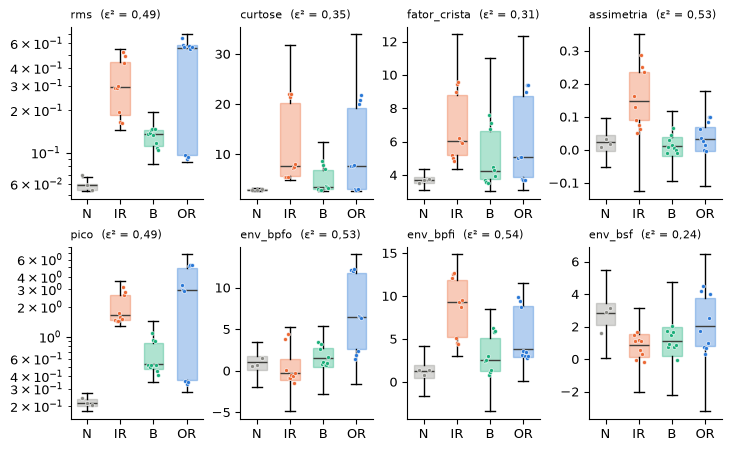

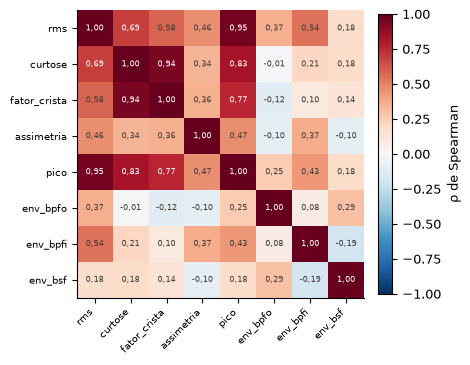

In [23]:
fig, eixos = plt.subplots(2, 4, figsize=(7.2, 4.4), constrained_layout=True)
for ax, f in zip(eixos.ravel(), NOMES_FEATURES):
    dados = [dados_tr.loc[dados_tr["classe"] == c, f] for c in ORDEM_CLASSES]
    caixas = ax.boxplot(dados, widths=0.6, showfliers=False, patch_artist=True,
                        medianprops={"color": "#3d3d3a", "lw": 1})
    for caixa, c in zip(caixas["boxes"], ORDEM_CLASSES):
        caixa.set(facecolor=CORES_EDA[c], alpha=0.35, edgecolor=CORES_EDA[c])
    for i, c in enumerate(ORDEM_CLASSES, 1):  # mediana de cada gravação
        y = med_grav.loc[med_grav["classe"] == c, f]
        ax.scatter(np.full(len(y), i) + np.linspace(-0.15, 0.15, len(y)), y, s=8,
                   color=CORES_EDA[c], edgecolor="white", lw=0.4, zorder=3)
    ax.set_xticks(range(1, 5), ["N", "IR", "B", "OR"])
    eps = kw.set_index("feature").loc[f, "epsilon2"]
    ax.set_title(f"{f}  (ε² = {eps:.2f})".replace(".", ","), fontsize=8, loc="left")
    if f in ("rms", "pico"):
        ax.set_yscale("log")
fig.savefig(DIR_FIGURES / "eda_boxplots_features.png", dpi=200)

fig, ax = plt.subplots(figsize=(4.6, 3.9), constrained_layout=True)
im = ax.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(NOMES_FEATURES)), NOMES_FEATURES, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(NOMES_FEATURES)), NOMES_FEATURES, fontsize=7)
for i in range(len(NOMES_FEATURES)):
    for j in range(len(NOMES_FEATURES)):
        r = corr.iat[i, j]
        ax.text(j, i, f"{r:.2f}".replace(".", ","), ha="center", va="center", fontsize=6,
                color="white" if abs(r) > 0.6 else "#3d3d3a")
fig.colorbar(im, ax=ax, shrink=0.8, label="ρ de Spearman")
fig.savefig(DIR_FIGURES / "eda_correlacao_features.png", dpi=200)

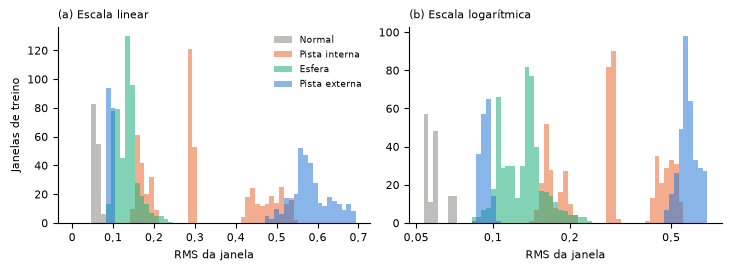

In [24]:
def figura_rms_assimetria() -> None:
    """Distribuição do RMS das janelas de treino por classe, em escala linear e
    logarítmica: multimodal dentro de cada classe (cada classe reúne gravações de níveis
    diferentes) e com dispersões muito diferentes
    entre classes, o que viola os pressupostos da ANOVA (normalidade e
    variâncias iguais) e motiva o Kruskal-Wallis."""
    plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False})
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.2, 2.6), constrained_layout=True)
    for c in ORDEM_CLASSES:
        v = dados_tr.loc[dados_tr["classe"] == c, "rms"].to_numpy()
        a1.hist(v, bins=np.linspace(0, dados_tr["rms"].max(), 60), color=CORES_EDA[c], alpha=0.55,
                label=NOMES_CLASSE[c])
        a2.hist(v, bins=np.geomspace(dados_tr["rms"].min(), dados_tr["rms"].max(), 60), color=CORES_EDA[c], alpha=0.55)
    a2.set_xscale("log")
    a2.set_xticks([0.05, 0.1, 0.2, 0.5])
    a2.minorticks_off()
    a1.set_title("(a) Escala linear", fontsize=8, loc="left")
    a2.set_title("(b) Escala logarítmica", fontsize=8, loc="left")
    for ax in (a1, a2):
        ax.set_xlabel("RMS da janela")
        ax.xaxis.set_major_formatter(VIRGULA)
    a1.set_ylabel("Janelas de treino")
    a1.legend(fontsize=6.5, frameon=False)
    fig.savefig(DIR_FIGURES / "eda_rms_distribuicao.png", dpi=200)


with plt.rc_context():  # não altera a fonte das figuras seguintes
    figura_rms_assimetria()

## Scaler

O `StandardScaler` vai **dentro do `Pipeline`** de cada modelo: em cada fold da
validação cruzada e no ajuste final, ele é ajustado só nos dados de treino.

# **Validação física**

Antes de qualquer modelo: o pico do espectro de envelope cai na frequência de
defeito prevista pela teoria? Uma gravação de falha é *confirmada* quando a
família dominante é a da classe declarada e supera o maior *score* das normais.
Três pré-processamentos são comparados aos métodos de Smith & Randall (2015):
sinal bruto (método 1), pré-branqueamento cepstral (método 2) e kurtograma.

In [25]:
# Comprimentos de janela da STFT avaliados. A largura de banda de cada raia é
# ~ fs / Nw: a 12 kHz, 1500, 750 e 375 Hz.
JANELAS_SK = (8, 16, 32)


# Banda mínima: 3 x a maior BPFI do conjunto (~162 Hz a 1797 rpm), para que a
# banda filtrada contenha a portadora e as bandas laterais da modulação.
BANDA_MIN_HZ = 3 * 5.4152 * 1797 / 60


def curtose_espectral(x: np.ndarray, fs: float, nw: int) -> tuple[np.ndarray, np.ndarray]:
    """SK(f) de um sinal 1D pela STFT com janela de Hann de nw amostras."""
    from scipy.signal import stft

    f, _, z = stft(x, fs=fs, window="hann", nperseg=nw, noverlap=3 * nw // 4, boundary=None)
    p2 = np.mean(np.abs(z) ** 2, axis=1)
    p4 = np.mean(np.abs(z) ** 4, axis=1)
    return f, p4 / p2**2 - 2.0


def banda_kurtograma(
    x: np.ndarray, fs: float, f_max: float = 4800.0, janelas=JANELAS_SK
) -> tuple[float, float, float]:
    """Banda (f_baixa, f_alta) de maior curtose espectral e o valor da SK.

    Percorre as resoluções de `janelas`, descarta bandas mais estreitas que
    BANDA_MIN_HZ ou que ultrapassem f_max (a banda comum), e devolve a melhor.
    """
    melhor = (np.nan, np.nan, -np.inf)
    for nw in janelas:
        largura = fs / nw
        if largura < BANDA_MIN_HZ:
            continue
        f, sk = curtose_espectral(x, fs, nw)
        validas = (f - largura / 2 > 0) & (f + largura / 2 <= f_max)
        if not validas.any():
            continue
        i = np.argmax(np.where(validas, sk, -np.inf))
        if sk[i] > melhor[2]:
            melhor = (f[i] - largura / 2, f[i] + largura / 2, float(sk[i]))
    return melhor


def filtrar_banda(x: np.ndarray, fs: float, f_baixa: float, f_alta: float) -> np.ndarray:
    """Passa-banda Butterworth de ordem 4, fase zero."""
    from scipy.signal import butter, sosfiltfilt

    sos = butter(4, [f_baixa, f_alta], btype="bandpass", fs=fs, output="sos")
    return sosfiltfilt(sos, x, axis=-1)


def prebranquear(x: np.ndarray) -> np.ndarray:
    """Pré-branqueamento cepstral: espectro com magnitude unitária e a fase
    original ("método 2" de Smith & Randall, 2015, p. 104). Iguala o peso de
    todas as faixas, de modo que as mais impulsivas passam a dominar o sinal,
    e remove os picos discretos fortes que mascaram o defeito."""
    espectro = np.fft.rfft(x, axis=-1)
    return np.fft.irfft(espectro / np.maximum(np.abs(espectro), 1e-12), n=x.shape[-1], axis=-1)


PREPROCESSAMENTOS = ("bruto", "prebranqueado", "kurtograma")


def preprocessar_envelope(x: np.ndarray, fs: float, metodo: str) -> np.ndarray:
    """Sinal pronto para o envelope, segundo o pré-processamento escolhido:
    - "bruto": o sinal na banda comum (método 1 de Smith & Randall);
    - "prebranqueado": pré-branqueamento cepstral (método 2);
    - "kurtograma": filtro na banda de maior curtose espectral, sem a separação
      de componentes discretos (DRS) que o método 3 do artigo aplica antes.
    """
    if metodo == "bruto":
        return x
    if metodo == "prebranqueado":
        return prebranquear(x)
    if metodo == "kurtograma":
        f_baixa, f_alta, _ = banda_kurtograma(x, fs)
        return filtrar_banda(x, fs, f_baixa, f_alta)
    raise ValueError(f"pré-processamento desconhecido: {metodo}")

In [26]:
# Família de frequência que cada classe deve fazer dominar no envelope.
FAMILIA_ESPERADA = {"IR": "bpfi", "OR": "bpfo", "B": "bsf"}


FAMILIAS = ("bpfo", "bpfi", "bsf")


def validacao_fisica(
    registros: pd.DataFrame | None = None, preprocessamento: str = "bruto"
) -> pd.DataFrame:
    """Escores de envelope de cada gravação inteira e o veredito físico.

    Para cada registro, o SES do sinal completo (~10 s, resolução ~0,1 Hz) dá
    um escore por família (BPFO, BPFI, BSF; ver `escores_envelope`). A família
    `dominante` é a de maior escore. Uma falha é `confirmada` quando:
      1. a família dominante é a esperada para a classe declarada; e
      2. o escore dessa família supera o maior escore que a mesma família
         atinge nas gravações normais, que são o nível de "ruído" do método.
    O resultado é cruzado com o diagnóstico de Smith & Randall pelo método
    equivalente (M1, envelope do sinal bruto) e pelo melhor dos três métodos.

    `preprocessamento` (ver `preprocessar_envelope`): "bruto" (M1),
    "prebranqueado" (M2) ou "kurtograma". O limiar de cada família vem das
    gravações normais com o MESMO pré-processamento.
    """
    m = ler_manifesto() if registros is None else registros
    linhas = []
    for _, reg in m.iterrows():
        x = preprocessar_envelope(carregar_sinal(reg), FS_HZ, preprocessamento)
        f, ses = espectro_envelope(x, FS_HZ)
        esc = escores_envelope(f, ses, reg["rpm"]).iloc[0]
        linhas.append(
            {
                "registro": reg["id"],
                "classe": reg["classe"],
                "diametro_pol": reg["diametro_pol"],
                "posicao_or_h": reg["posicao_or_h"],
                "carga_hp": reg["carga_hp"],
                **{f"env_{k}": esc[f"env_{k}"] for k in FAMILIAS},
            }
        )
    v = pd.DataFrame(linhas)
    cols = [f"env_{k}" for k in FAMILIAS]
    v["dominante"] = v[cols].idxmax(axis=1).str.removeprefix("env_")

    normais = v[v["classe"] == "normal"]
    if normais.empty:
        raise ValueError("a validação precisa das gravações normais como referência")
    limiar = {k: normais[f"env_{k}"].max() for k in FAMILIAS}

    def veredito(r):
        esperada = FAMILIA_ESPERADA.get(r["classe"])
        if esperada is None:
            return np.nan
        return bool(r["dominante"] == esperada and r[f"env_{esperada}"] > limiar[esperada])

    v["confirmada"] = v.apply(veredito, axis=1)
    aud = ler_auditoria()[["registro", "m1", "m2", "m3", "melhor", "grupo"]]
    return v.merge(aud, on="registro", how="left").assign(preprocessamento=preprocessamento)


def resumo_validacao(v: pd.DataFrame) -> pd.DataFrame:
    """Confirmadas por classe/posição, lado a lado com Smith & Randall.

    `smith_m1_Y`: gravações que o artigo diagnostica (Y1/Y2) com o envelope do
    sinal bruto, o método equivalente ao nosso. `smith_melhor_Y`: com o melhor
    dos três métodos.
    """
    f = v[v["classe"] != "normal"].copy()
    f["grupo_classe"] = np.where(
        f["classe"] == "OR", "OR @" + f["posicao_or_h"].astype(str), f["classe"]
    )
    f["smith_m1_Y"] = f["m1"].str.startswith("Y")
    f["smith_melhor_Y"] = f["grupo"] == "Y"
    f["confirmada"] = f["confirmada"].astype(bool)
    f["concorda_m1"] = f["confirmada"] == f["smith_m1_Y"]
    ordem = ["IR", "B", "OR @6", "OR @3", "OR @12"]
    r = f.groupby("grupo_classe").agg(
        gravacoes=("registro", "size"),
        confirmadas=("confirmada", "sum"),
        smith_m1_Y=("smith_m1_Y", "sum"),
        smith_melhor_Y=("smith_melhor_Y", "sum"),
        concorda_com_m1=("concorda_m1", "sum"),
    )
    return r.loc[[o for o in ordem if o in r.index]]


def comparar_preprocessamentos(registros: pd.DataFrame | None = None) -> pd.DataFrame:
    """Gravações de falha confirmadas por classe com cada pré-processamento,
    lado a lado com o que Smith & Randall diagnosticam (Y) por M1, M2 e M3.

    M2 e M3 só foram aplicados pelo artigo quando M1 ficou em P1 ou abaixo;
    quando estão vazios, o diagnóstico de M1 (Y) é contado também para eles.
    """
    vs = {p: validacao_fisica(registros, p) for p in ("bruto", "prebranqueado", "kurtograma")}
    base = vs["bruto"]
    f = base[base["classe"] != "normal"].copy()
    f["grupo_classe"] = np.where(
        f["classe"] == "OR", "OR @" + f["posicao_or_h"].astype(str), f["classe"]
    )
    linhas = {}
    for p, v in vs.items():
        f[p] = v.loc[f.index, "confirmada"].astype(bool).to_numpy()
    for k in ("m1", "m2", "m3"):
        f[f"smith_{k}"] = f[k].fillna(f["m1"]).str.startswith("Y")
    cols = ["bruto", "prebranqueado", "kurtograma", "smith_m1", "smith_m2", "smith_m3"]
    r = f.groupby("grupo_classe")[cols].sum()
    r.insert(0, "gravacoes", f.groupby("grupo_classe").size())
    ordem = ["IR", "B", "OR @6", "OR @3", "OR @12"]
    return r.loc[[o for o in ordem if o in r.index]]

In [27]:
# Uma gravação por classe, todas a 1 HP. Falhas de 0,021" (IR, OR @6) e a
# esfera 223, a única que Smith & Randall diagnosticam com o envelope simples.
EXEMPLOS = [(98, "Normal"), (210, "Pista interna"), (223, "Esfera"), (131, "Pista externa")]


# Paleta categórica de referência, validada para daltonismo.
CORES_FAMILIA = {"bpfo": "#2a78d6", "bpfi": "#eb6834", "bsf": "#1baf7a"}


ROTULOS = {"bpfo": "BPFO", "bpfi": "BPFI", "bsf": "BSF"}


COR_SES = "#3d3d3a"


F_MAX_HZ = 360.0


def figura_envelope_por_classe() -> None:
    m = ler_manifesto().set_index("id")
    plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False})
    fig, eixos = plt.subplots(len(EXEMPLOS), 1, figsize=(7.2, 7.4), sharex=True, constrained_layout=True)
    for ax, (rid, nome) in zip(eixos, EXEMPLOS):
        reg = m.loc[rid].copy()
        reg["id"] = rid
        f, ses = espectro_envelope(carregar_sinal(reg), FS_HZ)
        faixa = (f > 2) & (f <= F_MAX_HZ)
        ses_n = ses / np.median(ses[faixa])
        ax.plot(f[faixa], ses_n[faixa], color=COR_SES, lw=0.7)
        fc = frequencias_caracteristicas(reg["rpm"])
        topo = ses_n[faixa].max()
        for familia, hs in HARMONICOS.items():
            base = getattr(fc, familia)
            for h in hs:
                ax.axvline(h * base, color=CORES_FAMILIA[familia], lw=1.0, ls="--", zorder=0)
                rot = ROTULOS[familia] if h == 1 else f"{h}×{ROTULOS[familia]}"
                ax.text(h * base, topo * 1.02, rot, color="#5f5e5a", fontsize=7, ha="center", va="bottom")
        ax.set_ylim(0, topo * 1.18)
        ax.set_title(f"{nome} (registro {rid}, {reg['rpm']:.0f} rpm)", fontsize=9, loc="left")
        ax.set_ylabel("SES / mediana")
    eixos[-1].set_xlabel("Frequência (Hz)")
    eixos[-1].set_xlim(0, F_MAX_HZ)
    fig.savefig(DIR_FIGURES / "envelope_por_classe_1hp.png", dpi=200)


def figura_kurtograma(rid: int = 197) -> None:
    """Curtose espectral por resolução e o SES antes/depois do filtro na banda
    escolhida, para uma gravação que o envelope bruto não diagnostica."""
    m = ler_manifesto().set_index("id")
    reg = m.loc[rid].copy()
    reg["id"] = rid
    x = carregar_sinal(reg)
    f_baixa, f_alta, _ = banda_kurtograma(x, FS_HZ)
    bpfo = frequencias_caracteristicas(reg["rpm"]).bpfo

    fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(7.2, 6.6), constrained_layout=True)
    cores = ["#2a78d6", "#eb6834", "#1baf7a"]
    for nw, cor in zip(JANELAS_SK, cores):
        f, sk = curtose_espectral(x, FS_HZ, nw)
        a1.plot(f / 1e3, sk, color=cor, lw=1.2, marker="o", ms=3, label=f"banda de {FS_HZ / nw:.0f} Hz")
    a1.axvspan(f_baixa / 1e3, f_alta / 1e3, color="#e8e7e2", lw=0)
    a1.set_xlim(0, 4.8)
    a1.set_xlabel("Frequência (kHz)")
    a1.set_ylabel("Curtose espectral")
    a1.set_title(f"Registro {rid}: curtose espectral; banda escolhida {f_baixa:.0f}–{f_alta:.0f} Hz", fontsize=9, loc="left")
    a1.legend(fontsize=7, frameon=False)
    for ax, sinal, titulo in (
        (a2, x, "Envelope do sinal bruto (banda comum)"),
        (a3, filtrar_banda(x, FS_HZ, f_baixa, f_alta), "Envelope na banda do kurtograma"),
    ):
        f, ses = espectro_envelope(sinal, FS_HZ)
        faixa = (f > 2) & (f <= F_MAX_HZ)
        ses_n = ses / np.median(ses[faixa])
        ax.plot(f[faixa], ses_n[faixa], color=COR_SES, lw=0.7)
        topo = ses_n[faixa].max()
        for h in (1, 2, 3):
            ax.axvline(h * bpfo, color=CORES_FAMILIA["bpfo"], lw=1.0, ls="--", zorder=0)
            ax.text(h * bpfo, topo * 1.02, "BPFO" if h == 1 else f"{h}×BPFO", fontsize=7, color="#5f5e5a", ha="center", va="bottom")
        ax.set_ylim(0, topo * 1.18)
        ax.set_xlim(0, F_MAX_HZ)
        ax.set_title(titulo, fontsize=9, loc="left")
        ax.set_ylabel("SES / mediana")
    a3.set_xlabel("Frequência (Hz)")
    fig.savefig(DIR_FIGURES / f"kurtograma_registro_{rid}.png", dpi=200)

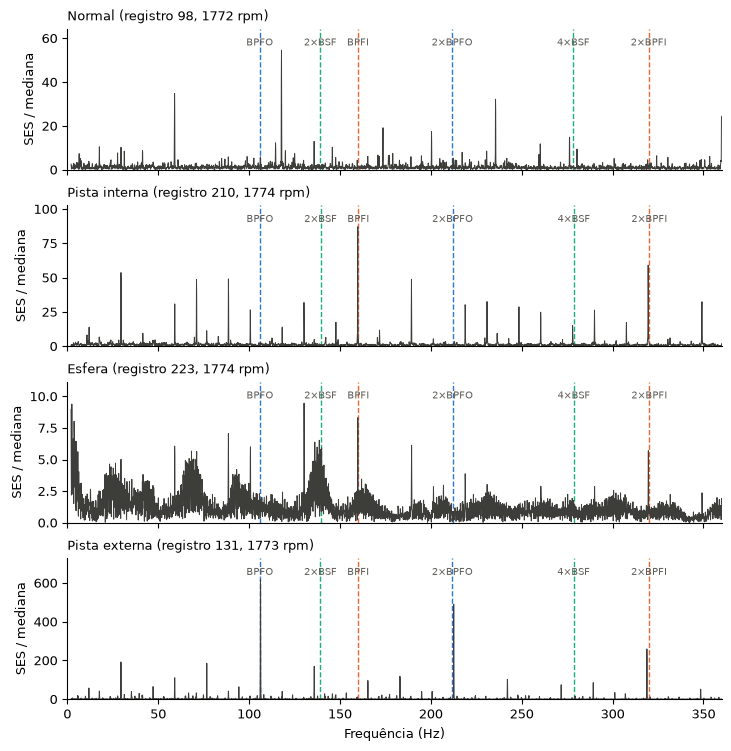

In [28]:
v = validacao_fisica()
v.to_csv(DIR_METRICS / "validacao_fisica.csv", index=False, float_format="%.2f")
resumo_validacao(v).to_csv(DIR_METRICS / "validacao_fisica_resumo.csv")
figura_envelope_por_classe()

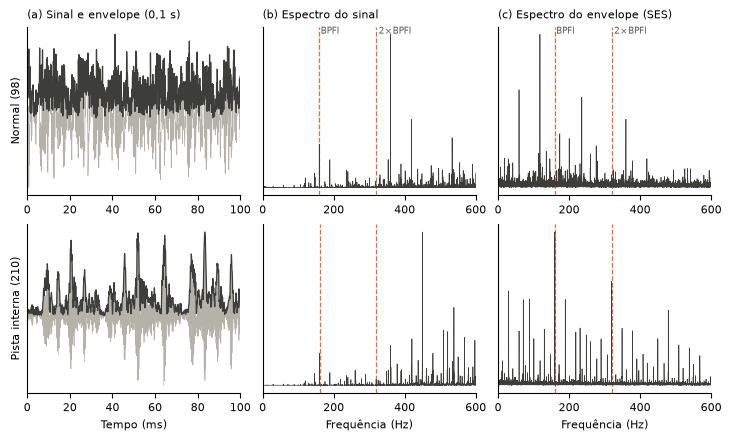

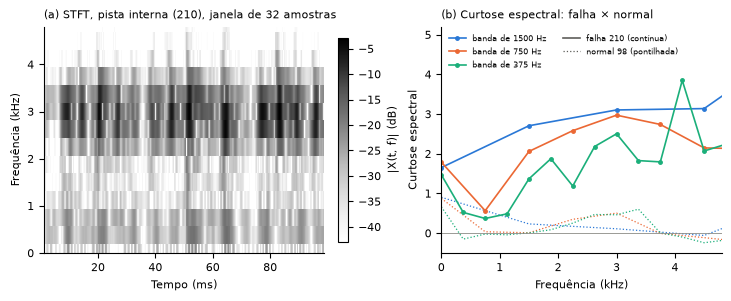

In [29]:
def figura_envelope_etapas(exemplos=((98, "Normal"), (210, "Pista interna")), f_max: float = 600.0) -> None:
    """Por que o envelope: forma de onda com o envelope |x_a(t)|, espectro do
    sinal e espectro do envelope ao quadrado (SES), para um normal e uma falha
    de pista interna, ambos a 1 HP. As linhas marcam BPFI e 2 x BPFI."""
    m = ler_manifesto().set_index("id")
    plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False})
    fig, eixos = plt.subplots(len(exemplos), 3, figsize=(7.2, 4.3), constrained_layout=True)
    for linha, (rid, nome) in zip(eixos, exemplos):
        reg = m.loc[rid].copy()
        reg["id"] = rid
        x = carregar_sinal(reg)
        bpfi = frequencias_caracteristicas(reg["rpm"]).bpfi
        n = int(0.1 * FS_HZ)
        t = np.arange(n) / FS_HZ * 1e3
        env = np.abs(hilbert(x))[:n]
        linha[0].plot(t, x[:n], color="#b4b2a9", lw=0.5, label="sinal")
        linha[0].plot(t, env, color="#3d3d3a", lw=0.9, label="envelope")
        linha[0].set_xlim(0, 100)
        linha[0].set_ylabel(f"{nome} ({rid})")
        linha[0].set_yticks([])

        f = np.fft.rfftfreq(len(x), 1 / FS_HZ)
        espectro = np.abs(np.fft.rfft(x * np.hanning(len(x))))
        fe, ses = espectro_envelope(x, FS_HZ)
        for ax, ff, yy in ((linha[1], f, espectro), (linha[2], fe, ses)):
            faixa = (ff > 2) & (ff <= f_max)
            yn = yy[faixa] / np.median(yy[faixa])
            ax.plot(ff[faixa], yn, color="#3d3d3a", lw=0.5)
            for h in (1, 2):
                ax.axvline(h * bpfi, color=CORES_FAMILIA["bpfi"], lw=0.9, ls="--", zorder=0)
            ax.set_xlim(0, f_max)
            ax.set_yticks([])
        if rid == exemplos[-1][0]:
            linha[0].set_xlabel("Tempo (ms)")
            linha[1].set_xlabel("Frequência (Hz)")
            linha[2].set_xlabel("Frequência (Hz)")
    eixos[0, 0].set_title("(a) Sinal e envelope (0,1 s)", fontsize=8, loc="left")
    eixos[0, 1].set_title("(b) Espectro do sinal", fontsize=8, loc="left")
    eixos[0, 2].set_title("(c) Espectro do envelope (SES)", fontsize=8, loc="left")
    for ax in eixos[0, 1:]:
        for h, rot in ((1, "BPFI"), (2, "2×BPFI")):
            ax.text(h * bpfi * 1.02, ax.get_ylim()[1], rot, fontsize=6.5, color="#5f5e5a", va="top")
    fig.savefig(DIR_FIGURES / "envelope_sinal_vs_ses.png", dpi=200)


with plt.rc_context():  # não altera a fonte das figuras seguintes
    figura_envelope_etapas()


def figura_stft_curtose_espectral(rid_falha: int = 210, rid_normal: int = 98) -> None:
    """(a) STFT de 0,1 s de uma falha de pista interna: cada impacto aparece como
    uma faixa vertical, concentrada nas bandas de ressonância. (b) Curtose
    espectral da falha e do normal com as três resoluções do kurtograma: perto
    de zero onde o sinal é estacionário, alta onde há impactos."""
    from scipy.signal import stft

    m = ler_manifesto().set_index("id")
    sinais = {}
    for rid in (rid_falha, rid_normal):
        reg = m.loc[rid].copy()
        reg["id"] = rid
        sinais[rid] = carregar_sinal(reg)

    plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False})
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.2, 2.9), constrained_layout=True)
    n = int(0.1 * FS_HZ)
    f, t, z = stft(sinais[rid_falha][:n], fs=FS_HZ, window="hann", nperseg=32, noverlap=28, boundary=None)
    db = 20 * np.log10(np.abs(z) + 1e-12)
    im = a1.pcolormesh(t * 1e3, f / 1e3, db, cmap="Greys", shading="auto", vmin=db.max() - 40, vmax=db.max(),
                       rasterized=True)
    a1.set_ylim(0, 4.8)
    a1.set_xlabel("Tempo (ms)")
    a1.set_ylabel("Frequência (kHz)")
    a1.set_title(f"(a) STFT, pista interna ({rid_falha}), janela de 32 amostras", fontsize=8, loc="left")
    fig.colorbar(im, ax=a1, label="|X(t, f)| (dB)", shrink=0.9)

    cores = ["#2a78d6", "#eb6834", "#1baf7a"]
    for nw, cor in zip(JANELAS_SK, cores):
        ff, sk = curtose_espectral(sinais[rid_falha], FS_HZ, nw)
        a2.plot(ff / 1e3, sk, color=cor, lw=1.2, marker="o", ms=2.5, label=f"banda de {FS_HZ / nw:.0f} Hz")
        ff, sk = curtose_espectral(sinais[rid_normal], FS_HZ, nw)
        a2.plot(ff / 1e3, sk, color=cor, lw=0.9, ls=":")
    a2.axhline(0, color="#8a8a85", lw=0.6)
    a2.set_xlim(0, 4.8)
    a2.set_xlabel("Frequência (kHz)")
    a2.set_ylabel("Curtose espectral")
    a2.set_title("(b) Curtose espectral: falha × normal", fontsize=8, loc="left")
    a2.plot([], [], color="#5f5e5a", lw=1.2, label=f"falha {rid_falha} (contínua)")
    a2.plot([], [], color="#5f5e5a", lw=0.9, ls=":", label=f"normal {rid_normal} (pontilhada)")
    a2.legend(fontsize=6, frameon=False, loc="upper left", ncols=2)
    a2.set_ylim(-0.5, 5.2)
    for ax in (a1, a2):
        ax.xaxis.set_major_formatter(VIRGULA)
        ax.yaxis.set_major_formatter(VIRGULA)
    fig.savefig(DIR_FIGURES / "stft_curtose_espectral.png", dpi=200)


with plt.rc_context():  # não altera a fonte das figuras seguintes
    figura_stft_curtose_espectral()

Gravações de falha confirmadas — nosso critério × Smith & Randall (Y por método):


,gravacoes,bruto,prebranqueado,kurtograma,smith_m1,smith_m2,smith_m3
grupo_classe,,,,,,,
IR,12,12,12,12,11,12,12
B,12,0,5,0,1,2,2
OR @6,12,8,8,10,8,8,9
OR @3,8,8,8,8,8,8,8
OR @12,8,8,8,8,8,8,8


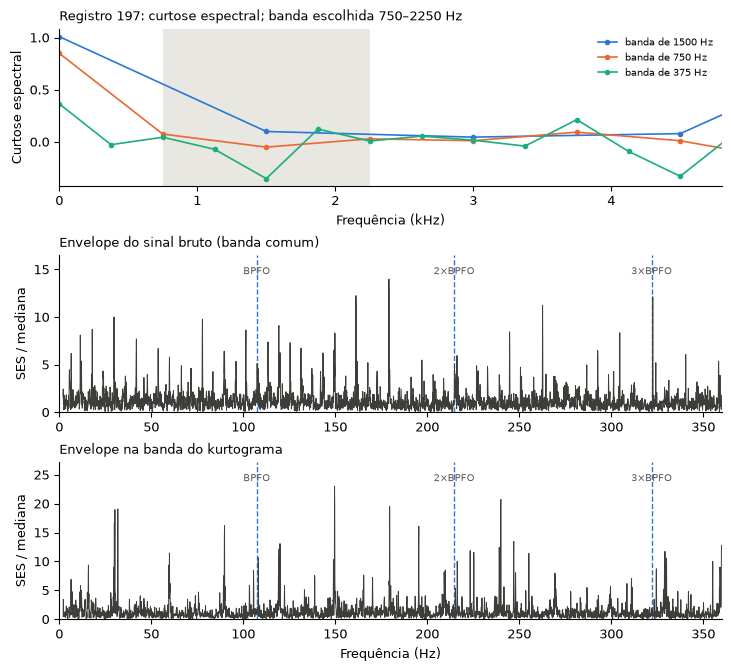

In [30]:
comp = comparar_preprocessamentos()
comp.to_csv(DIR_METRICS / "validacao_fisica_preprocessamentos.csv")
for p in ("prebranqueado", "kurtograma"):
    validacao_fisica(preprocessamento=p).to_csv(DIR_METRICS / f"validacao_fisica_{p}.csv", index=False, float_format="%.2f")
figura_kurtograma()
print("Gravações de falha confirmadas — nosso critério × Smith & Randall (Y por método):")
comp

# **Detecção one-class** — *detectar que algo mudou*

Treinada **somente com normais** de 0/1/2 HP (`treinar_detector` recusa qualquer
janela de falha). Cada detector é um `Pipeline(StandardScaler, modelo)`; o limiar
de alarme é o percentil 99 dos *scores* normais de treino. Métricas: AUC, TPR
(= recall), FPR, precisão e F1 — estas duas lidas contra a prevalência de falhas.

In [31]:
# Limiar: percentil 99 dos escores normais de treino, isto é, uma taxa de
# falsos positivos de cerca de 1% esperada nos dados de treino.
PERCENTIL_LIMIAR = 99.0


BASELINES = ("mahalanobis", "isolation_forest")


DETECTORES = BASELINES + ("ocsvm", "autoencoder")


class Mahalanobis(OutlierMixin, BaseEstimator):
    """Distância de Mahalanobis à média dos normais (Mahalanobis, 1936).
    `score_samples` segue a convenção do scikit-learn: maior = mais normal."""

    def fit(self, x, y=None):
        self.cov_ = EmpiricalCovariance().fit(x)
        return self

    def score_samples(self, x):
        return -np.sqrt(self.cov_.mahalanobis(x))


class Autoencoder(OutlierMixin, BaseEstimator):
    """Autoencoder raso (Hinton; Salakhutdinov, 2006): MLP treinada para
    reconstruir a própria entrada por um gargalo de 3 neurônios; o escore é o
    erro quadrático médio de reconstrução. Implementado com o MLPRegressor do
    scikit-learn, suficiente para 8 features e sem exigir PyTorch."""

    def fit(self, x, y=None):
        self.mlp_ = MLPRegressor(
            hidden_layer_sizes=(6, 3, 6), activation="tanh", alpha=1e-3,
            max_iter=5000, random_state=SEED,
        ).fit(x, x)
        return self

    def score_samples(self, x):
        return -np.mean((self.mlp_.predict(x) - x) ** 2, axis=1)


def novo_detector(nome: str):
    """Modelo one-class não treinado (último passo do pipeline)."""
    if nome == "mahalanobis":
        return Mahalanobis()
    if nome == "isolation_forest":
        # Liu; Ting; Zhou (2008): menos cortes até isolar = mais anômalo.
        return IsolationForest(n_estimators=300, random_state=SEED)
    if nome == "ocsvm":
        # Schölkopf et al. (2001); nu = fração máxima de normais fora da fronteira.
        return OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)
    if nome == "autoencoder":
        return Autoencoder()
    raise ValueError(f"detector desconhecido: {nome}")


@dataclass
class Detector:
    """Pipeline treinado (scaler + modelo one-class) e limiar de alarme."""

    nome: str
    features: list[str]
    pipeline: Pipeline
    limiar: float

    def escore(self, f: pd.DataFrame) -> np.ndarray:
        """Escore de anomalia: maior = mais anômalo."""
        return -self.pipeline.score_samples(f[self.features])

    def alarme(self, f: pd.DataFrame) -> np.ndarray:
        return self.escore(f) > self.limiar


def treinar_detector(
    nome: str, f_treino: pd.DataFrame, classes_treino, features: list[str]
) -> Detector:
    """Treina um detector one-class. Falha se houver janela não normal no treino.

    O pipeline padroniza as features com o StandardScaler ajustado só nos
    normais de treino.
    """
    classes = pd.Series(np.asarray(classes_treino))
    if len(classes) != len(f_treino):
        raise ValueError("classes_treino e f_treino têm tamanhos diferentes")
    if not (classes == "normal").all():
        outras = sorted(set(classes) - {"normal"})
        raise ValueError(f"treino one-class com classes não normais: {outras}")

    x = f_treino[list(features)]
    pipe = Pipeline([("scaler", StandardScaler()), ("modelo", novo_detector(nome))]).fit(x)
    det = Detector(nome, list(features), pipe, np.nan)
    det.limiar = float(np.percentile(det.escore(f_treino), PERCENTIL_LIMIAR))
    return det

In [32]:
def metricas_deteccao(eh_falha, escore, alarme) -> dict:
    """AUC da curva ROC e, no limiar de alarme, TPR, FPR, precisão e F1.

    `eh_falha`: verdadeiro para janelas de falha (positivas).
    - TPR (recall) = fração das falhas com alarme;
    - FPR = fração das normais com alarme;
    - precisão = fração dos alarmes que são falhas;
    - prevalência = fração de falhas no conjunto. A precisão só tem sentido
      comparada a ela: um detector que alarma sempre tem precisão igual à
      prevalência e recall 1.
    """
    from sklearn.metrics import roc_auc_score

    eh_falha = np.asarray(eh_falha, dtype=bool)
    alarme = np.asarray(alarme, dtype=bool)
    tem_as_duas = eh_falha.any() and (~eh_falha).any()
    tp = int((alarme & eh_falha).sum())
    precisao = tp / alarme.sum() if alarme.any() else np.nan
    tpr = alarme[eh_falha].mean() if eh_falha.any() else np.nan
    return {
        "auc": roc_auc_score(eh_falha, escore) if tem_as_duas else np.nan,
        "tpr": tpr,
        "fpr": alarme[~eh_falha].mean() if (~eh_falha).any() else np.nan,
        "precisao": precisao,
        "f1": 2 * precisao * tpr / (precisao + tpr) if (precisao + tpr) > 0 else np.nan,
        "prevalencia": eh_falha.mean(),
        "n_falha": int(eh_falha.sum()),
        "n_normal": int((~eh_falha).sum()),
    }


def erros_deteccao(meta: pd.DataFrame, escore, alarme, limiar: float) -> pd.DataFrame:
    """Janelas em que o detector errou: falha sem alarme (FN) ou normal com
    alarme (FP), com carga, classe, severidade e escore."""
    eh_falha = (meta["classe"] != "normal").to_numpy()
    alarme = np.asarray(alarme, dtype=bool)
    errou = eh_falha != alarme
    e = meta.loc[errou, ["registro", "janela", "classe", "diametro_pol", "posicao_or_h", "carga_hp"]].copy()
    e["predito"] = np.where(alarme[errou], "anomalia", "normal")
    e["tipo_erro"] = np.where(eh_falha[errou], "FN", "FP")
    e["escore"] = np.asarray(escore)[errou]
    e["limiar"] = limiar
    return e


def alarmes_por_registro(meta: pd.DataFrame, alarme) -> pd.DataFrame:
    """Fração de janelas com alarme por gravação, com a auditoria de Smith &
    Randall (grupo Y/P/N) para estratificar as métricas."""
    d = meta[["registro", "classe", "diametro_pol", "posicao_or_h", "carga_hp"]].copy()
    d["alarme"] = np.asarray(alarme, dtype=bool)
    r = (
        d.groupby(["registro", "classe", "diametro_pol", "posicao_or_h", "carga_hp"], dropna=False)
        .agg(janelas=("alarme", "size"), taxa_alarme=("alarme", "mean"))
        .reset_index()
    )
    aud = ler_auditoria()[["registro", "m1", "grupo"]]
    return r.merge(aud, on="registro", how="left")


def rodar_deteccao(F, meta, Fg, meta_g, conjuntos=None, detectores=DETECTORES):
    """Treina cada detector com os normais de 0/1/2 HP e avalia em 3 HP.

    Devolve (metricas, por_registro, erros, escores_teste):
    - metricas: AUC/TPR/FPR no teste e TPR no conjunto de generalização
      (pista externa a 3 h e 12 h, todas as cargas, nunca vista no treino);
    - por_registro: taxa de alarme por gravação de teste;
    - erros: janelas de teste erradas, por experimento;
    - escores_teste: escores de cada experimento, para as curvas ROC.
    """
    conjuntos = conjuntos or list(CONJUNTOS_FEATURES)
    treino, teste = split_por_carga(meta)
    normal_treino = treino & (meta["classe"] == "normal").to_numpy()
    meta_te = meta[teste].reset_index(drop=True)
    eh_falha_te = (meta_te["classe"] != "normal").to_numpy()

    linhas, registros, erros, escores = [], [], [], {}
    for conj in conjuntos:
        cols = CONJUNTOS_FEATURES[conj]
        for nome in detectores:
            det = treinar_detector(nome, F[normal_treino], meta.loc[normal_treino, "classe"], cols)
            s = det.escore(F[teste])
            a = s > det.limiar
            ag = det.alarme(Fg)
            m = metricas_deteccao(eh_falha_te, s, a)
            linhas.append(
                {
                    "features": conj,
                    "detector": nome,
                    **m,
                    "tpr_generalizacao": ag.mean(),
                    "limiar": det.limiar,
                }
            )
            pr = alarmes_por_registro(meta_te, a).assign(features=conj, detector=nome)
            registros.append(pr)
            erros.append(erros_deteccao(meta_te, s, a, det.limiar).assign(features=conj, detector=nome))
            escores[(conj, nome)] = s
    return (
        pd.DataFrame(linhas),
        pd.concat(registros, ignore_index=True),
        pd.concat(erros, ignore_index=True),
        (eh_falha_te, escores),
    )


def tpr_por_grupo_smith(por_registro: pd.DataFrame) -> pd.DataFrame:
    """TPR por categoria de diagnosticabilidade de Smith & Randall (Y/P/N).

    Média das taxas de alarme das gravações de falha de cada grupo (cada
    gravação pesa igual, já que as janelas de uma gravação são correlacionadas).
    """
    f = por_registro[por_registro["classe"] != "normal"]
    return (
        f.groupby(["features", "detector", "grupo"])["taxa_alarme"]
        .mean()
        .unstack("grupo")
        .reindex(columns=["Y", "P", "N"])
    )

In [33]:
# Paleta categórica de referência (ordem fixa), validada para daltonismo.
CORES_DET = dict(zip(DETECTORES, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))


NOMES_DET = {
    "mahalanobis": "Mahalanobis",
    "isolation_forest": "Isolation Forest",
    "ocsvm": "One-Class SVM",
    "autoencoder": "Autoencoder",
}


CORES_CLASSE = {"normal": "#8a8a85", "IR": "#eb6834", "B": "#1baf7a", "OR": "#2a78d6"}


def figura_roc(metricas: pd.DataFrame, eh_falha: np.ndarray, escores: dict) -> None:
    fig, eixos = plt.subplots(2, 2, figsize=(7.2, 6.6), sharex=True, sharey=True, constrained_layout=True)
    for ax, conj in zip(eixos.ravel(), CONJUNTOS_FEATURES):
        ax.plot([0, 1], [0, 1], color="#c3c2b7", lw=0.8, ls=":")
        ax.text(0.62, 0.55, "acaso (AUC 0,5)", rotation=45, fontsize=6.5, color="#8a8a85", ha="center")
        for nome in DETECTORES:
            fpr, tpr, _ = roc_curve(eh_falha, escores[(conj, nome)])
            linha = metricas.query("features == @conj and detector == @nome")
            auc = linha["auc"].item()
            ax.plot(fpr, tpr, color=CORES_DET[nome], lw=1.5, label=f"{NOMES_DET[nome]} (AUC {auc:.2f})".replace(".", ","))
            # Ponto de operação: TPR e FPR no limiar adotado (p99 dos normais de treino).
            ax.scatter(linha["fpr"].item(), linha["tpr"].item(), s=30, color=CORES_DET[nome],
                       edgecolor="white", lw=0.8, zorder=4)
        ax.scatter([], [], s=30, color="#5f5e5a", edgecolor="white", label="limiar adotado (p99)")
        ax.set_title(f"Features: {conj}", fontsize=9, loc="left")
        ax.legend(loc="lower right", fontsize=7, frameon=False)
        ax.set_aspect("equal")
    for ax in eixos[1]:
        ax.set_xlabel("FPR")
    for ax in eixos[:, 0]:
        ax.set_ylabel("TPR")
    fig.savefig(DIR_FIGURES / "deteccao_roc_por_conjunto_de_features.png", dpi=200)


def figura_rms(F: pd.DataFrame, meta: pd.DataFrame) -> None:
    """RMS mediano de cada gravação: mostra que a amplitude sozinha separa
    normal de falha, inclusive nas gravações sem assinatura física."""
    d = pd.concat([meta[["registro", "classe", "carga_hp"]], F["rms"]], axis=1)
    g = d.groupby(["registro", "classe", "carga_hp"])["rms"].median().reset_index()
    ordem = ["normal", "IR", "B", "OR"]
    fig, ax = plt.subplots(figsize=(7.2, 2.8), constrained_layout=True)
    teto_normal = g.loc[g["classe"] == "normal", "rms"].max()
    ax.axhline(teto_normal, color="#8a8a85", lw=0.8, ls="--")
    ax.text(3.45, teto_normal, " maior RMS normal", va="bottom", ha="right", fontsize=7, color="#5f5e5a")
    for i, c in enumerate(ordem):
        s = g[g["classe"] == c].sort_values("registro")
        x = i + np.linspace(-0.3, 0.3, len(s))
        teste = s["carga_hp"] == 3
        ax.scatter(x[~teste.to_numpy()], s["rms"][~teste], s=28, color=CORES_CLASSE[c], edgecolor="white", lw=0.8, label=None)
        ax.scatter(x[teste.to_numpy()], s["rms"][teste], s=28, facecolor="white", edgecolor=CORES_CLASSE[c], lw=1.4)
        for xi, (_, r) in zip(x, s.iterrows()):
            if r["registro"] in (200, 225):  # teste, sem assinatura física
                ax.annotate(str(r["registro"]), (xi, r["rms"]), xytext=(0, 6), textcoords="offset points", ha="center", fontsize=6.5, color="#5f5e5a")
    ax.set_xticks(range(len(ordem)), [NOMES_CLASSE[c] for c in ordem])
    ax.set_yscale("log")
    ticks = [0.05, 0.1, 0.2, 0.5, 1.0]
    ax.set_yticks(ticks, [f"{t:g}".replace(".", ",") for t in ticks])
    ax.minorticks_off()
    ax.set_ylabel("RMS mediano por gravação")
    ax.scatter([], [], s=28, color="#5f5e5a", label="treino (0–2 HP)")
    ax.scatter([], [], s=28, facecolor="white", edgecolor="#5f5e5a", lw=1.4, label="teste (3 HP)")
    ax.legend(loc="upper left", fontsize=7, frameon=False)
    fig.savefig(DIR_FIGURES / "rms_por_gravacao.png", dpi=200)

,features,detector,auc,tpr,fpr,precisao,f1,tpr_generalizacao
0,tempo,mahalanobis,1.000,1.000,0.034,0.996,0.998,1.000
1,tempo,isolation_forest,0.995,0.776,0.000,1.000,0.874,1.000
2,tempo,ocsvm,1.000,1.000,0.293,0.969,0.984,1.000
3,tempo,autoencoder,1.000,1.000,0.000,1.000,1.000,1.000
4,envelope,mahalanobis,0.718,0.576,0.138,0.974,0.724,0.762
5,envelope,isolation_forest,0.688,0.434,0.086,0.978,0.601,0.455
6,envelope,ocsvm,0.771,0.759,0.500,0.932,0.837,0.856
7,envelope,autoencoder,0.828,0.545,0.034,0.993,0.704,0.689
8,tempo+envelope,mahalanobis,1.000,1.000,0.121,0.987,0.993,1.000
9,tempo+envelope,isolation_forest,0.985,0.902,0.069,0.992,0.945,1.000


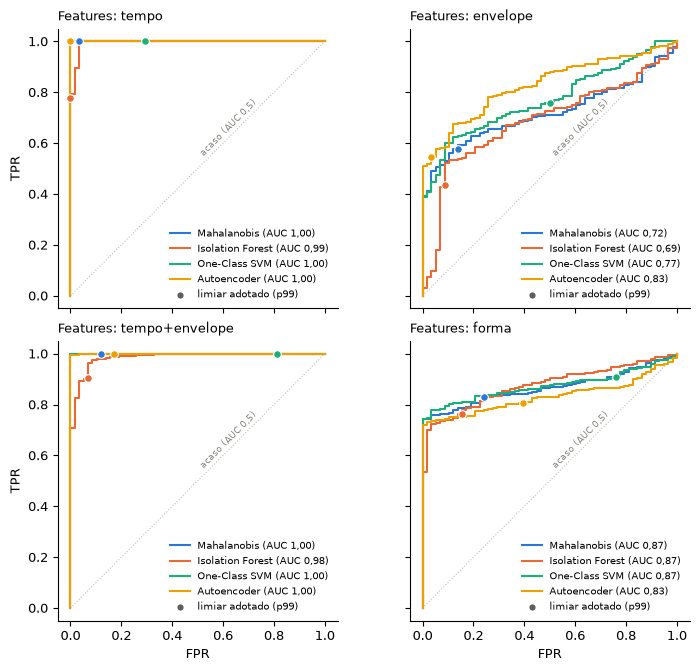

In [34]:
met_det, por_reg_det, erros_det, (eh_falha_te, escores_te) = rodar_deteccao(F, meta, Fg, meta_g)
met_det.to_csv(DIR_METRICS / "deteccao_metricas.csv", index=False, float_format="%.4f")
por_reg_det.to_csv(DIR_METRICS / "deteccao_por_registro.csv", index=False, float_format="%.4f")
tpr_por_grupo_smith(por_reg_det).to_csv(DIR_METRICS / "deteccao_tpr_por_grupo_smith.csv", float_format="%.4f")
erros_det.to_csv(DIR_METRICS / "deteccao_erros.csv", index=False, float_format="%.4f")
figura_roc(met_det, eh_falha_te, escores_te)
met_det[["features", "detector", "auc", "tpr", "fpr", "precisao", "f1", "tpr_generalizacao"]].round(3)

AUC = 1,00 com features de tempo é **suspeito**. Não é vazamento (split por
gravação verificado), mas o RMS sozinho separa normal de falha — inclusive nas
gravações sem assinatura física (grupo N). E a precisão alta engana: 90% das
janelas de teste são de falha, então alarmar sempre já daria precisão 0,90.

AUC só com RMS: 1.0
Prevalência de falhas no teste: 0.9


grupo                               Y     P     N
features       detector                          
envelope       autoencoder       0.67  0.02  0.42
               isolation_forest  0.55  0.00  0.29
               mahalanobis       0.73  0.00  0.41
               ocsvm             0.91  0.14  0.61
forma          autoencoder       0.85  1.00  0.59
               isolation_forest  0.84  0.95  0.44
               mahalanobis       0.85  1.00  0.67
               ocsvm             0.91  1.00  0.86
tempo          autoencoder       1.00  1.00  1.00
               isolation_forest  0.84  1.00  0.47
               mahalanobis       1.00  1.00  1.00
               ocsvm             1.00  1.00  1.00
tempo+envelope autoencoder       1.00  1.00  1.00
               isolation_forest  0.93  1.00  0.78
               mahalanobis       1.00  1.00  1.00
               ocsvm             1.00  1.00  1.00

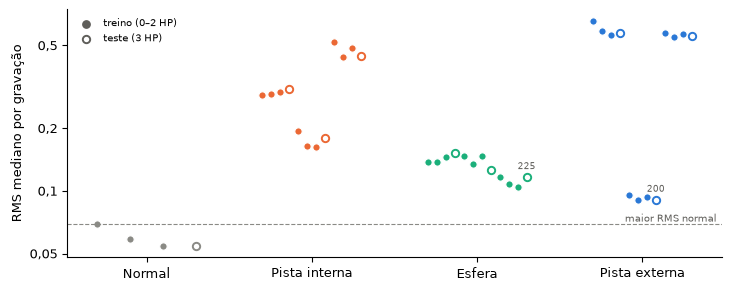

In [35]:
y_te_bin = (meta.loc[teste, "classe"] != "normal").to_numpy()
print("AUC só com RMS:", roc_auc_score(y_te_bin, F.loc[teste, "rms"]).round(3))
print("Prevalência de falhas no teste:", y_te_bin.mean().round(3))
figura_rms(F, meta)
tpr_por_grupo_smith(por_reg_det).round(2)

### Pressupostos do baseline de Mahalanobis

A distância de Mahalanobis ao quadrado segue uma qui-quadrado com *k* graus de
liberdade **se** as features normais forem normais multivariadas. Verificamos a
normalidade de cada feature nas janelas normais de treino (Shapiro–Wilk) e
comparamos o limiar empírico (percentil 99) com o limiar teórico da qui-quadrado.

In [36]:
normal_tr = treino & (meta["classe"] == "normal").to_numpy()
z = StandardScaler().fit_transform(F.loc[normal_tr, NOMES_FEATURES])
normalidade = pd.DataFrame([
    {"feature": f, "W": shapiro(z[:, i]).statistic, "p_valor": shapiro(z[:, i]).pvalue,
     "assimetria": stats.skew(z[:, i]), "curtose_excesso": stats.kurtosis(z[:, i])}
    for i, f in enumerate(NOMES_FEATURES)
])

k = len(NOMES_FEATURES)
det_m = treinar_detector("mahalanobis", F[normal_tr], meta.loc[normal_tr, "classe"], NOMES_FEATURES)
limiar_chi2 = float(np.sqrt(chi2.ppf(0.99, k)))
esc_tr, esc_te = det_m.escore(F[normal_tr]), det_m.escore(F[teste])
eh_falha_t = (meta.loc[teste, "classe"] != "normal").to_numpy()
comparacao_limiar = pd.DataFrame([
    {"limiar": nome, "valor": lim,
     "fracao_normais_treino_acima": (esc_tr > lim).mean(),
     "TPR_teste": (esc_te[eh_falha_t] > lim).mean(), "FPR_teste": (esc_te[~eh_falha_t] > lim).mean()}
    for nome, lim in (("empírico (p99 do treino)", det_m.limiar), ("qui-quadrado (99%, k=8)", limiar_chi2))
])
normalidade.to_csv(DIR_METRICS / "deteccao_normalidade_features.csv", index=False, float_format="%.4g")
comparacao_limiar.to_csv(DIR_METRICS / "deteccao_limiar_qui_quadrado.csv", index=False, float_format="%.4f")
display(normalidade.round(4))
comparacao_limiar.round(3)

,feature,W,p_valor,assimetria,curtose_excesso
0,rms,0.8088,0.0000,1.0599,-0.1779
1,curtose,0.9807,0.0404,-0.4016,0.2112
2,fator_crista,0.8926,0.0000,1.4320,2.7965
3,assimetria,0.9906,0.4541,0.1353,-0.4538
4,pico,0.9480,0.0000,0.8894,0.8780
5,env_bpfo,0.9902,0.4128,-0.2462,0.5040
6,env_bpfi,0.9937,0.7804,0.0229,-0.3730
7,env_bsf,0.9642,0.0008,-0.7605,1.4792


,limiar,valor,fracao_normais_treino_acima,TPR_teste,FPR_teste
0,empírico (p99 do treino),5.121,0.014,1.0,0.121
1,"qui-quadrado (99%, k=8)",4.482,0.062,1.0,0.224


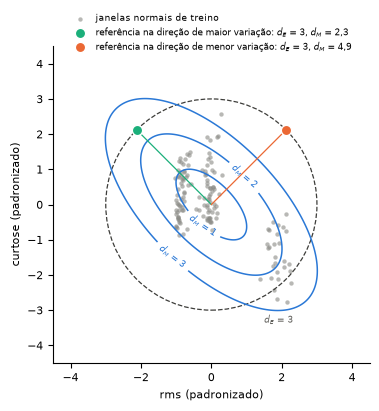

In [37]:
def figura_mahalanobis(fx: str = "rms", fy: str = "curtose", raio: float = 3.0) -> None:
    """Geometria da distância de Mahalanobis em duas features correlacionadas das
    janelas normais de treino (padronizadas). Elipses: distância de Mahalanobis
    constante; círculo tracejado: distância euclidiana constante. Os dois pontos
    marcados são de referência (não são janelas): estão no mesmo círculo, mas um
    na direção em que os normais variam muito e outro na direção em que variam
    pouco, e por isso têm distâncias de Mahalanobis muito diferentes."""
    esc = StandardScaler().fit(F.loc[normal_tr, [fx, fy]])
    z_tr = esc.transform(F.loc[normal_tr, [fx, fy]])
    cov = np.cov(z_tr, rowvar=False)
    icov = np.linalg.inv(cov)
    d_m = lambda z: np.sqrt(np.einsum("ij,jk,ik->i", z, icov, z))
    autovalores, autovetores = np.linalg.eigh(cov)  # crescente: [menor, maior]

    plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False})
    fig, ax = plt.subplots(figsize=(4.8, 4.0), constrained_layout=True)
    ax.scatter(z_tr[:, 0], z_tr[:, 1], s=10, color=COR_NORMAL, alpha=0.6, lw=0, label="janelas normais de treino")
    g = np.linspace(-5, 5, 400)
    gx, gy = np.meshgrid(g, g)
    dd = d_m(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)
    cs = ax.contour(gx, gy, dd, levels=[1, 2, 3], colors="#2a78d6", linewidths=1.1)
    ax.clabel(cs, fmt=lambda v: f"$d_M$ = {v:g}", fontsize=6.5)
    ax.add_patch(plt.Circle((0, 0), raio, fill=False, ls="--", color="#3d3d3a", lw=0.9))
    ax.text(raio * 0.5, -raio * 1.12, f"$d_E$ = {raio:g}", fontsize=6.5, color="#5f5e5a")
    for idx, cor, direcao in ((1, "#1baf7a", "maior variação"), (0, "#eb6834", "menor variação")):
        z = raio * autovetores[:, idx]
        if z[1] < 0:
            z = -z
        rot = f"referência na direção de {direcao}: $d_E$ = {raio:g}, $d_M$ = {d_m(z[None])[0]:.1f}".replace(".", ",")
        ax.plot([0, z[0]], [0, z[1]], color=cor, lw=0.9, zorder=3)
        ax.scatter(*z, s=55, color=cor, edgecolor="white", lw=1, zorder=4, label=rot)
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_aspect("equal")
    ax.set_xlabel(f"{fx} (padronizado)")
    ax.set_ylabel(f"{fy} (padronizado)")
    ax.legend(fontsize=6.3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.13))
    fig.savefig(DIR_FIGURES / "mahalanobis_geometria.png", dpi=200)


with plt.rc_context():  # não altera a fonte das figuras seguintes
    figura_mahalanobis()

### Qual detector recomendar

Três candidatos, todos treinados só com normais: o melhor detector por AUC
(Mahalanobis, tempo+envelope), o melhor detector só com envelope (autoencoder,
maior AUC entre os de sentido físico) e uma **combinação em dois estágios** —
alarme só quando o detector de amplitude **e** o de envelope disparam juntos.
Como a prevalência de falhas no teste (90%) não representa uma planta, a
precisão é projetada pela regra de Bayes para 1% e 5% de janelas de falha, a
partir da TPR e da FPR medidas.

In [38]:
cand = {}
for nome, det_nome, conj in (("Mahalanobis (tempo+envelope)", "mahalanobis", "tempo+envelope"),
                             ("Autoencoder (envelope)", "autoencoder", "envelope")):
    d = treinar_detector(det_nome, F[normal_tr], meta.loc[normal_tr, "classe"], CONJUNTOS_FEATURES[conj])
    cand[nome] = (d.alarme(F[teste]), roc_auc_score(eh_falha_t, d.escore(F[teste])))
cand["Dois estágios (ambos alarmam)"] = (cand["Mahalanobis (tempo+envelope)"][0] & cand["Autoencoder (envelope)"][0], np.nan)

grupo_smith = meta.loc[teste, ["registro"]].merge(ler_auditoria()[["registro", "grupo"]], on="registro", how="left")["grupo"].to_numpy()
linhas = []
for nome, (alarme, auc) in cand.items():
    tpr, fpr = alarme[eh_falha_t].mean(), alarme[~eh_falha_t].mean()
    proj = {f"precisao_{int(p*100)}pct": tpr * p / (tpr * p + fpr * (1 - p)) if (tpr * p + fpr * (1 - p)) > 0 else np.nan
            for p in (0.01, 0.05)}
    linhas.append({"detector": nome, "auc": auc, "tpr": tpr, "fpr": fpr,
                   **{f"alarme_{g}": alarme[grupo_smith == g].mean() for g in ("Y", "P", "N")}, **proj})
recomendado = pd.DataFrame(linhas)
recomendado.to_csv(DIR_METRICS / "deteccao_recomendado.csv", index=False, float_format="%.4f")
recomendado.round(3)

,detector,auc,tpr,fpr,alarme_Y,alarme_P,alarme_N,precisao_1pct,precisao_5pct
0,Mahalanobis (tempo+envelope),1.000,1.000,0.121,1.000,1.000,1.000,0.077,0.304
1,Autoencoder (envelope),0.828,0.545,0.034,0.673,0.017,0.422,0.138,0.454
2,Dois estágios (ambos alarmam),NaN,0.545,0.034,0.673,0.017,0.422,0.138,0.454


# **Select Models** — *identificar o que mudou*

Validação cruzada **no treino**, com `LeaveOneGroupOut` e grupo = carga (cada fold
deixa uma carga de fora — a mesma lógica do teste). Para comparação, a mesma conta
com `StratifiedKFold` embaralhado, que espalha janelas da mesma gravação entre
treino e validação.

3. **Informe para cada modelo a acurácia obtida no treinamento (validação cruzada).**

In [39]:
def pipeline(classificador) -> Pipeline:
    """Scaler + classificador. O StandardScaler é ajustado só no treino de cada
    fold, dentro do pipeline, o que evita vazamento da padronização."""
    return Pipeline([("scaler", StandardScaler()), ("clf", classificador)])


def modelos_candidatos() -> dict[str, Pipeline]:
    """Os modelos comparados na seleção, com hiperparâmetros padrão."""
    return {
        "Regressão Logística": pipeline(
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
        ),
        "KNN (k=3)": pipeline(KNeighborsClassifier(n_neighbors=3)),
        "KNN (k=9)": pipeline(KNeighborsClassifier(n_neighbors=9)),
        "Random Forest": pipeline(
            RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1)
        ),
        "SVM (RBF)": pipeline(SVC(kernel="rbf", class_weight="balanced", random_state=SEED)),
    }


def cv_por_carga() -> LeaveOneGroupOut:
    """Validação cruzada que deixa uma carga de fora por fold."""
    return LeaveOneGroupOut()


def cv_embaralhado() -> StratifiedKFold:
    """Validação INCORRETA para este problema (janelas embaralhadas): usada só
    para quantificar o vazamento na discussão."""
    return StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def selecionar_modelos(x: pd.DataFrame, y, cargas) -> pd.DataFrame:
    """Acurácia média de cada candidato na validação cruzada do treino.

    Calcula as duas validações: por carga (a correta) e embaralhada (a que
    vaza), para comparar.
    """
    linhas = []
    for nome, modelo in modelos_candidatos().items():
        por_carga = cross_val_score(modelo, x, y, groups=cargas, cv=cv_por_carga(), scoring="accuracy")
        embaralhado = cross_val_score(modelo, x, y, cv=cv_embaralhado(), scoring="accuracy")
        linhas.append(
            {
                "modelo": nome,
                "cv_por_carga": por_carga.mean(),
                "cv_por_carga_desvio": por_carga.std(),
                "cv_embaralhado": embaralhado.mean(),
            }
        )
    return pd.DataFrame(linhas).sort_values("cv_por_carga", ascending=False).reset_index(drop=True)

In [40]:
cols = CONJUNTOS_FEATURES["tempo+envelope"]
x_tr, y_tr, g_tr = F.loc[treino, cols], meta.loc[treino, "classe"], meta.loc[treino, "carga_hp"]
selecao = selecionar_modelos(x_tr, y_tr, g_tr)
display(selecao.round(3))
print("Melhor preditor (CV por carga):", selecao.loc[0, "modelo"])

,modelo,cv_por_carga,cv_por_carga_desvio,cv_embaralhado
0,Random Forest,0.979,0.010,0.994
1,SVM (RBF),0.924,0.011,0.952
2,KNN (k=3),0.923,0.017,0.944
3,KNN (k=9),0.920,0.015,0.936
4,Regressão Logística,0.862,0.021,0.881


Melhor preditor (CV por carga): Random Forest


# **GridSearch**

Hiperparâmetros do Random Forest e do SVM por `GridSearchCV` sobre o pipeline,
com a mesma validação por carga.

In [41]:
# Grades do GridSearchCV para os dois modelos estudados em detalhe.
GRADES = {
    "Random Forest": {
        "clf__n_estimators": [100, 300, 500],
        "clf__max_depth": [None, 5, 10],
        "clf__min_samples_leaf": [1, 5],
    },
    "SVM (RBF)": {
        "clf__C": [0.1, 1, 10, 100],
        "clf__gamma": ["scale", 0.01, 0.1, 1],
    },
}


def ajustar_hiperparametros(nome: str, x: pd.DataFrame, y, cargas) -> GridSearchCV:
    """GridSearchCV do modelo `nome` sobre sua grade, com CV por carga. O
    melhor pipeline é reajustado com todo o treino (refit)."""
    busca = GridSearchCV(
        modelos_candidatos()[nome],
        GRADES[nome],
        cv=cv_por_carga(),
        scoring="accuracy",
        n_jobs=-1,
        refit=True,
    )
    return busca.fit(x, y, groups=cargas)

In [42]:
buscas = {nome: ajustar_hiperparametros(nome, x_tr, y_tr, g_tr) for nome in GRADES}
for nome, b in buscas.items():
    print(f"{nome}: melhor CV = {b.best_score_:.3f} | {b.best_params_}")

Random Forest: melhor CV = 0.984 | {'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
SVM (RBF): melhor CV = 0.980 | {'clf__C': 10, 'clf__gamma': 0.1}


# **Melhor modelo**

4. **Analise o modelo final no teste (3 HP). Ele é um bom modelo? Discuta com base em métricas.**

In [43]:
def acuracia_por_classe(y_true, y_pred, classes=ORDEM_CLASSES) -> pd.Series:
    """Fração de acertos dentro de cada classe verdadeira (recall por classe)."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return pd.Series(
        {c: (y_pred[y_true == c] == c).mean() if (y_true == c).any() else np.nan for c in classes}
    )


def matriz_confusao(y_true, y_pred, classes=ORDEM_CLASSES) -> pd.DataFrame:
    """Matriz completa, com todas as classes nas linhas (verdadeira) e colunas
    (predita), mesmo as que não aparecem nas previsões."""
    m = pd.crosstab(
        pd.Categorical(y_true, categories=classes),
        pd.Categorical(y_pred, categories=classes),
        dropna=False,
    )
    m.index.name, m.columns.name = "verdadeira", "predita"
    return m


def erros_classificacao(meta: pd.DataFrame, y_pred) -> pd.DataFrame:
    """Janelas classificadas errado, com carga, classe verdadeira, predita e
    severidade."""
    y_pred = np.asarray(y_pred)
    errou = meta["classe"].to_numpy() != y_pred
    e = meta.loc[errou, ["registro", "janela", "classe", "diametro_pol", "posicao_or_h", "carga_hp"]].copy()
    e = e.rename(columns={"classe": "verdadeira"})
    e["predita"] = y_pred[errou]
    return e

In [44]:
model = buscas["Random Forest"].best_estimator_
y_te = meta.loc[teste, "classe"]
y_pred = model.predict(F.loc[teste, cols])
print(f"Acurácia no teste: {accuracy_score(y_te, y_pred):.4f}\n")
print(classification_report(y_te, y_pred, labels=ORDEM_CLASSES, digits=3))
pd.DataFrame(confusion_matrix(y_te, y_pred, labels=ORDEM_CLASSES),
             index=[f"verdadeira {c}" for c in ORDEM_CLASSES],
             columns=[f"predita {c}" for c in ORDEM_CLASSES])

Acurácia no teste: 0.9570

              precision    recall  f1-score   support

      normal      1.000     1.000     1.000        58
          IR      1.000     0.977     0.988       175
           B      0.878     0.994     0.933       174
          OR      0.994     0.885     0.936       174

    accuracy                          0.957       581
   macro avg      0.968     0.964     0.964       581
weighted avg      0.962     0.957     0.957       581



,predita normal,predita IR,predita B,predita OR
verdadeira normal,58,0,0,0
verdadeira IR,0,171,4,0
verdadeira B,0,0,173,1
verdadeira OR,0,0,20,154


In [45]:
imp = pd.Series(model.named_steps["clf"].feature_importances_, index=cols).sort_values(ascending=False)
print("Importância das features (Random Forest):")
print(imp.round(3).to_string())
print(f"\nRMS + pico = {imp[['rms', 'pico']].sum():.1%} da importância; escore de BSF = {imp['env_bsf']:.1%}")

Importância das features (Random Forest):
rms             0.298
pico            0.265
env_bpfo        0.131
curtose         0.101
env_bpfi        0.093
fator_crista    0.047
env_bsf         0.033
assimetria      0.032

RMS + pico = 56.3% da importância; escore de BSF = 3.3%


### Ganho de informação

Quanto da incerteza sobre a classe cada feature remove num único corte (a conta
do nó raiz de uma árvore com critério de entropia), e uma árvore rasa cujas regras
podem ser lidas.

In [46]:
def entropia(contagens: np.ndarray) -> float:
    """Entropia de Shannon (bits) de uma distribuição de classes."""
    p = contagens[contagens > 0] / contagens.sum()
    return float(-(p * np.log2(p)).sum())


def ganho_informacao_raiz(x: pd.DataFrame, y) -> pd.DataFrame:
    """Melhor ganho de informação de cada feature num corte binário único.

    É a conta que uma árvore de decisão com critério de entropia (ID3/C4.5;
    Quinlan, 1986) faz no nó raiz: para cada limiar t, ganho =
    H(Y) - [n_esq H(Y|x<=t) + n_dir H(Y|x>t)] / n. Devolve, por feature, o
    maior ganho, o limiar e as classes majoritárias de cada lado.
    """
    y = np.asarray(y)
    classes, yi = np.unique(y, return_inverse=True)
    k, n = len(classes), len(y)
    h_total = entropia(np.bincount(yi, minlength=k).astype(float))
    linhas = []
    for col in x.columns:
        v = x[col].to_numpy()
        ordem = np.argsort(v, kind="stable")
        vs, ys = v[ordem], yi[ordem]
        cum = np.zeros((n, k))
        cum[np.arange(n), ys] = 1
        cum = cum.cumsum(axis=0)
        total = cum[-1]
        melhor = (-1.0, np.nan, None, None)
        for i in np.nonzero(np.diff(vs) > 0)[0]:
            esq, dir_ = cum[i], total - cum[i]
            h = ((i + 1) * entropia(esq) + (n - i - 1) * entropia(dir_)) / n
            g = h_total - h
            if g > melhor[0]:
                melhor = (g, (vs[i] + vs[i + 1]) / 2, classes[esq.argmax()], classes[dir_.argmax()])
        linhas.append(
            {"feature": col, "ganho_bits": melhor[0], "ganho_relativo": melhor[0] / h_total,
             "limiar": melhor[1], "maioria_abaixo": melhor[2], "maioria_acima": melhor[3]}
        )
    return pd.DataFrame(linhas).sort_values("ganho_bits", ascending=False).reset_index(drop=True)

In [47]:
ganho = ganho_informacao_raiz(F.loc[treino, NOMES_FEATURES], meta.loc[treino, "classe"])
ganho.to_csv(DIR_METRICS / "classificacao_ganho_informacao.csv", index=False, float_format="%.4f")
display(ganho.round(3))

arvore = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=SEED).fit(
    F.loc[treino, NOMES_FEATURES], meta.loc[treino, "classe"])
texto_arvore = export_text(arvore, feature_names=NOMES_FEATURES, show_weights=True, decimals=2)
(DIR_METRICS / "arvore_entropia.txt").write_text(texto_arvore, encoding="utf-8")
pd.DataFrame([{
    "acuracia_teste": (arvore.predict(F.loc[teste, NOMES_FEATURES]) == y_te).mean(),
    "generalizacao_OR": (arvore.predict(Fg[NOMES_FEATURES]) == "OR").mean(),
    **{f"importancia_{c}": v for c, v in zip(NOMES_FEATURES, arvore.feature_importances_)},
}]).to_csv(DIR_METRICS / "arvore_entropia_metricas.csv", index=False, float_format="%.4f")
print(texto_arvore)

,feature,ganho_bits,ganho_relativo,limiar,maioria_abaixo,maioria_acima
0,pico,0.561,0.300,1.266,B,IR
1,rms,0.493,0.264,0.150,B,IR
2,curtose,0.397,0.213,4.884,B,IR
3,env_bpfo,0.365,0.196,5.391,B,OR
4,env_bpfi,0.360,0.192,3.261,B,IR
5,fator_crista,0.325,0.174,4.369,B,IR
6,assimetria,0.297,0.159,0.078,B,IR
7,env_bsf,0.170,0.091,2.476,IR,OR


|--- pico <= 1.27
|   |--- pico <= 0.39
|   |   |--- rms <= 0.08
|   |   |   |--- weights: [0.00, 0.00, 0.00, 144.00] class: normal
|   |   |--- rms >  0.08
|   |   |   |--- weights: [7.00, 0.00, 150.00, 0.00] class: OR
|   |--- pico >  0.39
|   |   |--- rms <= 0.10
|   |   |   |--- weights: [31.00, 0.00, 23.00, 0.00] class: B
|   |   |--- rms >  0.10
|   |   |   |--- weights: [426.00, 0.00, 1.00, 0.00] class: B
|--- pico >  1.27
|   |--- env_bpfo <= 4.85
|   |   |--- env_bpfi <= 3.07
|   |   |   |--- weights: [58.00, 0.00, 11.00, 0.00] class: B
|   |   |--- env_bpfi >  3.07
|   |   |   |--- weights: [0.00, 492.00, 0.00, 0.00] class: IR
|   |--- env_bpfo >  4.85
|   |   |--- pico <= 2.16
|   |   |   |--- weights: [0.00, 30.00, 0.00, 0.00] class: IR
|   |   |--- pico >  2.16
|   |   |   |--- weights: [0.00, 0.00, 337.00, 0.00] class: OR



**Discussão.** A acurácia é alta (~96%), mas não é evidência de diagnóstico:

- a **esfera** tem recall 0,99 e precisão 0,88 — atua como classe residual —, embora
  a validação física não tenha confirmado o defeito em nenhuma gravação de esfera
  pelo envelope bruto, e a gravação 225 (sem assinatura) seja acertada em 100%;
- RMS e pico somam mais da metade da importância, e a árvore de entropia define a
  esfera como uma **faixa de amplitude**, sem usar o *score* de BSF.

As seções seguintes testam isso em montagens que o modelo nunca viu.

## Comparação de conjuntos de features e CNN 1D

Os mesmos passos (seleção + GridSearch + teste) para cada conjunto de features, e
uma CNN 1D sobre o sinal bruto como contraponto (exige PyTorch, já instalado no
Colab; sem ele, a CNN é ignorada).

In [48]:
def _precisao_f1(y, p) -> dict:
    """Precisão por classe e F1 macro. A acurácia por classe já é o recall."""
    from sklearn.metrics import f1_score, precision_score


    prec = precision_score(y, p, labels=ORDEM_CLASSES, average=None, zero_division=0)
    return {
        **{f"prec_{c}": v for c, v in zip(ORDEM_CLASSES, prec)},
        "f1_macro": f1_score(y, p, labels=ORDEM_CLASSES, average="macro", zero_division=0),
    }


def rodar_classificacao(F, meta, Fg, meta_g, conjuntos=None, modelos=("Random Forest", "SVM (RBF)")):
    """Roteiro das aulas, para cada conjunto de features:

    1. seleção de modelos: acurácia de todos os candidatos na validação cruzada
       do treino (por carga, e embaralhada só para comparação);
    2. GridSearchCV dos modelos em `modelos`, com CV por carga;
    3. o melhor pipeline de cada busca é avaliado no teste (3 HP) e aplicado
       ao conjunto de generalização (pista externa a 3 h e 12 h).

    Devolve um dicionário com metricas, selecao, melhores_parametros,
    matrizes, relatorios (classification_report), por_registro, severidade,
    generalizacao, erros e importancias (Random Forest).
    """
    from sklearn.metrics import classification_report


    conjuntos = conjuntos or list(CONJUNTOS_FEATURES)
    treino, teste = split_por_carga(meta)
    meta_te = meta[teste].reset_index(drop=True)
    y_tr = meta.loc[treino, "classe"]
    cargas_tr = meta.loc[treino, "carga_hp"]
    aud = ler_auditoria()[["registro", "grupo"]]

    metricas, selecao, params, matrizes, relatorios = [], [], [], {}, {}
    por_reg, sev, gen, erros, imp = [], [], [], [], []
    for conj in conjuntos:
        cols = CONJUNTOS_FEATURES[conj]
        x_tr = F.loc[treino, cols]
        selecao.append(selecionar_modelos(x_tr, y_tr, cargas_tr).assign(features=conj))
        for nome in modelos:
            busca = ajustar_hiperparametros(nome, x_tr, y_tr, cargas_tr)
            clf = busca.best_estimator_
            p = clf.predict(F.loc[teste, cols])
            pg = clf.predict(Fg[cols])
            y = meta_te["classe"].to_numpy()
            tag = {"features": conj, "classificador": nome}
            params.append({**tag, "cv_por_carga": busca.best_score_, **busca.best_params_})

            acc = acuracia_por_classe(y, p)
            metricas.append(
                {**tag, "cv_por_carga": busca.best_score_, "acuracia": (p == y).mean(),
                 **{f"acc_{c}": v for c, v in acc.items()}, **_precisao_f1(y, p),
                 "generalizacao_OR": (pg == "OR").mean()}
            )
            matrizes[(conj, nome)] = matriz_confusao(y, p)
            relatorios[(conj, nome)] = pd.DataFrame(
                classification_report(y, p, output_dict=True, zero_division=0)
            ).transpose()

            d = meta_te.assign(predita=p, acerto=p == y)
            r = (
                d.groupby(["registro", "classe", "diametro_pol", "carga_hp"], dropna=False)
                .agg(acerto=("acerto", "mean"), predita_majoritaria=("predita", lambda s: s.mode().iat[0]))
                .reset_index()
                .merge(aud, on="registro", how="left")
            )
            por_reg.append(r.assign(**tag))
            sev.append(
                d[d["classe"] != "normal"].groupby(["classe", "diametro_pol"])["acerto"].mean()
                .reset_index().assign(**tag)
            )
            gen.append(
                meta_g.assign(predita=pg)
                .groupby(["posicao_or_h", "diametro_pol", "carga_hp", "predita"])
                .size().rename("janelas").reset_index().assign(**tag)
            )
            erros.append(erros_classificacao(meta_te, p).assign(**tag))
            if nome == "Random Forest":
                imp.append(
                    pd.DataFrame({"feature": cols, "importancia": clf.named_steps["clf"].feature_importances_})
                    .assign(**tag)
                )

    return {
        "metricas": pd.DataFrame(metricas),
        "selecao": pd.concat(selecao, ignore_index=True),
        "melhores_parametros": pd.DataFrame(params),
        "matrizes": matrizes,
        "relatorios": relatorios,
        "por_registro": pd.concat(por_reg, ignore_index=True),
        "severidade": pd.concat(sev, ignore_index=True),
        "generalizacao": pd.concat(gen, ignore_index=True),
        "erros": pd.concat(erros, ignore_index=True),
        "importancias": pd.concat(imp, ignore_index=True),
    }

In [49]:
ENTRADAS = ("bruto", "normalizado")


EPOCAS = 30


LOTE = 64


TAXA_APRENDIZADO = 1e-3


def _preparar(janelas: np.ndarray, entrada: str) -> np.ndarray:
    x = np.asarray(janelas, dtype=np.float32)
    if entrada == "normalizado":
        x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-8)
    elif entrada != "bruto":
        raise ValueError(f"entrada desconhecida: {entrada}")
    return x[:, None, :]


def _rede(n_classes: int):
    import torch.nn as nn

    def bloco(c_in, c_out, k, s=1):
        return [nn.Conv1d(c_in, c_out, k, stride=s, padding=k // 2), nn.BatchNorm1d(c_out), nn.ReLU(), nn.MaxPool1d(2)]

    return nn.Sequential(
        *bloco(1, 16, 64, 16),  # 4096 -> 256 -> 128
        *bloco(16, 32, 3),  # -> 64
        *bloco(32, 64, 3),  # -> 32
        *bloco(64, 64, 3),  # -> 16
        nn.AdaptiveAvgPool1d(1),
        nn.Flatten(),
        nn.Dropout(0.3),
        nn.Linear(64, n_classes),
    )


class ClassificadorCNN:
    """Interface tipo scikit-learn (fit/predict) para a CNN 1D."""

    def __init__(self, entrada: str = "bruto", epocas: int = EPOCAS, seed: int = SEED):
        self.entrada = entrada
        self.epocas = epocas
        self.seed = seed
        self.classes_ = list(ORDEM_CLASSES)

    def fit(self, janelas: np.ndarray, y) -> "ClassificadorCNN":
        import torch

        torch.manual_seed(self.seed)
        torch.use_deterministic_algorithms(True, warn_only=True)
        rng = np.random.default_rng(self.seed)

        x = torch.from_numpy(_preparar(janelas, self.entrada))
        idx = {c: i for i, c in enumerate(self.classes_)}
        yi = torch.tensor([idx[c] for c in np.asarray(y)])
        # Pesos inversos à frequência: o treino tem 144 normais contra ~520 por falha.
        contagem = torch.bincount(yi, minlength=len(self.classes_)).float()
        pesos = contagem.sum() / (len(self.classes_) * contagem.clamp(min=1))

        self.modelo_ = _rede(len(self.classes_))
        otim = torch.optim.Adam(self.modelo_.parameters(), lr=TAXA_APRENDIZADO)
        perda = torch.nn.CrossEntropyLoss(weight=pesos)
        self.modelo_.train()
        for _ in range(self.epocas):
            ordem = rng.permutation(len(x))
            for i in range(0, len(x), LOTE):
                lote = ordem[i : i + LOTE]
                otim.zero_grad()
                perda(self.modelo_(x[lote]), yi[lote]).backward()
                otim.step()
        return self

    def predict(self, janelas: np.ndarray) -> np.ndarray:
        import torch

        self.modelo_.eval()
        x = torch.from_numpy(_preparar(janelas, self.entrada))
        with torch.no_grad():
            saida = torch.cat([self.modelo_(x[i : i + 256]) for i in range(0, len(x), 256)])
        return np.asarray(self.classes_)[saida.argmax(dim=1).numpy()]


def rodar_cnn(meta=None, entradas=None):
    """CNN 1D sobre as janelas (issue #21), treino 0/1/2 HP e teste 3 HP.

    Exige PyTorch. Devolve (metricas, matrizes, por_registro).
    """

    X, meta = montar_janelas("principal")
    Xg, _ = montar_janelas("generalizacao")
    treino, teste = split_por_carga(meta)
    meta_te = meta[teste].reset_index(drop=True)
    y = meta_te["classe"].to_numpy()
    metricas, matrizes, por_reg = [], {}, []
    for entrada in entradas or ENTRADAS:
        clf = ClassificadorCNN(entrada).fit(X[treino], meta.loc[treino, "classe"])
        p = clf.predict(X[teste])
        pg = clf.predict(Xg)
        tag = {"features": f"sinal {entrada}", "classificador": "CNN 1D"}
        acc = acuracia_por_classe(y, p)
        metricas.append(
            {**tag, "acuracia": (p == y).mean(), **{f"acc_{c}": v for c, v in acc.items()},
             **_precisao_f1(y, p), "generalizacao_OR": (pg == "OR").mean()}
        )
        matrizes[(f"sinal {entrada}", "CNN 1D")] = matriz_confusao(y, p)
        d = meta_te.assign(acerto=p == y, predita=p)
        por_reg.append(
            d.groupby(["registro", "classe"]).agg(
                acerto=("acerto", "mean"), predita_majoritaria=("predita", lambda s: s.mode().iat[0])
            ).reset_index().assign(**tag)
        )
    return pd.DataFrame(metricas), matrizes, pd.concat(por_reg, ignore_index=True)

In [50]:
def _slug(texto: str) -> str:
    return (
        texto.lower().replace(" (rbf)", "").replace(" ", "_").replace("+", "_").replace("(", "").replace(")", "")
    )


def matriz_latex(m, conj: str, clf: str) -> str:
    rotulo = f"tab:confusao-{_slug(clf)}-{_slug(conj)}".replace("_", "-")
    cab = " & ".join(rf"\textbf{{{NOMES_CLASSE[c]}}}" for c in m.columns)
    linhas = [
        rf"    {NOMES_CLASSE[i]} & " + " & ".join(str(v) for v in m.loc[i]) + r" \\" for i in m.index
    ]
    entrada = f"entrada ``{conj}''" if conj.startswith("sinal") else f"features ``{conj}''"
    return "\n".join(
        [
            r"\begin{table}[htb]",
            r"  \centering",
            rf"  \caption{{Matriz de confusão: {clf}, {entrada}, teste em \SI{{3}}{{\hp}} (janelas).}}",
            rf"  \label{{{rotulo}}}",
            r"  \begin{tabular}{lcccc}",
            r"    \toprule",
            rf"    \textbf{{Verdadeira $\backslash$ Predita}} & {cab} \\",
            r"    \midrule",
            *linhas,
            r"    \bottomrule",
            r"  \end{tabular}",
            r"  \fonte{Gerada pelo notebook \texttt{notebooks/projeto.ipynb}.}",
            r"\end{table}",
            "",
        ]
    )

In [51]:
clf = rodar_classificacao(F, meta, Fg, meta_g)
metricas_cls, matrizes = clf["metricas"], dict(clf["matrizes"])
try:
    m_cnn, mat_cnn, reg_cnn = rodar_cnn()
    metricas_cls = pd.concat([metricas_cls, m_cnn], ignore_index=True)
    matrizes.update(mat_cnn)
    reg_cnn.to_csv(DIR_METRICS / "classificacao_cnn_por_registro.csv", index=False, float_format="%.4f")
except ImportError:
    print("PyTorch não instalado: CNN 1D ignorada.")

metricas_cls.to_csv(DIR_METRICS / "classificacao_metricas.csv", index=False, float_format="%.4f")
clf["selecao"].to_csv(DIR_METRICS / "classificacao_selecao_modelos.csv", index=False, float_format="%.4f")
clf["melhores_parametros"].to_csv(DIR_METRICS / "classificacao_melhores_parametros.csv", index=False, float_format="%.4f")
for chave in ("por_registro", "severidade", "generalizacao", "erros", "importancias"):
    clf[chave].to_csv(DIR_METRICS / f"classificacao_{chave}.csv", index=False, float_format="%.4f")
for antigo in list(DIR_METRICS.glob("classificacao_relatorio_*.csv")) + list(DIR_METRICS.glob("classificacao_matriz_*.csv")):
    antigo.unlink()
for (conj, nome), rel in clf["relatorios"].items():
    rel.to_csv(DIR_METRICS / f"classificacao_relatorio_{_slug(nome)}_{_slug(conj)}.csv", float_format="%.4f")
latex = ["% Gerado automaticamente pelo notebook (notebooks/projeto.ipynb). Não editar."]
for (conj, nome), m in matrizes.items():
    m.to_csv(DIR_METRICS / f"classificacao_matriz_{_slug(nome)}_{_slug(conj)}.csv")
    latex.append(matriz_latex(m, conj, nome))
(DIR_METRICS / "matrizes_confusao.tex").write_text("\n".join(latex), encoding="utf-8")
metricas_cls.round(3)

,features,classificador,cv_por_carga,acuracia,acc_normal,acc_IR,acc_B,acc_OR,prec_normal,prec_IR,prec_B,prec_OR,f1_macro,generalizacao_OR
0,tempo,Random Forest,0.972,0.933,1.000,0.909,0.971,0.897,1.000,0.975,0.833,0.994,0.945,0.500
1,tempo,SVM (RBF),0.974,0.928,1.000,0.897,0.966,0.897,1.000,0.975,0.824,0.987,0.941,0.500
2,envelope,Random Forest,0.753,0.676,0.000,0.937,0.649,0.667,0.000,0.886,0.543,0.690,0.545,0.760
3,envelope,SVM (RBF),0.713,0.671,0.052,0.966,0.603,0.649,0.055,0.904,0.533,0.796,0.567,0.677
4,tempo+envelope,Random Forest,0.984,0.957,1.000,0.977,0.994,0.885,1.000,1.000,0.878,0.994,0.964,0.400
5,tempo+envelope,SVM (RBF),0.980,0.950,1.000,0.994,0.966,0.874,0.951,1.000,0.889,0.968,0.954,0.115
6,forma,Random Forest,0.860,0.654,0.069,0.720,0.667,0.770,0.235,1.000,0.492,0.663,0.556,0.581
7,forma,SVM (RBF),0.865,0.756,0.241,0.977,0.730,0.730,0.280,1.000,0.651,0.770,0.671,0.295
8,sinal bruto,CNN 1D,NaN,0.971,1.000,0.903,1.000,1.000,1.000,1.000,0.911,1.000,0.976,0.356
9,sinal normalizado,CNN 1D,NaN,0.997,1.000,0.989,1.000,1.000,1.000,1.000,0.989,1.000,0.997,0.641


# **Generalização entre montagens**

No CWRU, cada combinação de defeito e diâmetro foi ensaiada numa única montagem,
presente nas quatro cargas — o split por carga não testa montagens novas. Aqui o
tipo de falha (IR, B, OR) é avaliado com `LeaveOneGroupOut` por **diâmetro**
(acaso = 33%) e comparado a uma **regra física sem treino**: a classe da família de
envelope dominante.

In [52]:
# Família de envelope dominante -> classe prevista pela física (sem treino).
REGRA_FISICA = {"env_bpfo": "OR", "env_bpfi": "IR", "env_bsf": "B"}


def prever_regra_fisica(F: pd.DataFrame) -> pd.Series:
    """Classe de falha pela família de envelope de maior escore em cada janela.
    Não usa treino: não tem como memorizar montagens."""
    return F[list(REGRA_FISICA)].idxmax(axis=1).map(REGRA_FISICA)


def classificacao_por_montagem(F, meta, Fg=None, meta_g=None, conjuntos=None, modelos=None):
    """Tipo de falha (IR, B, OR) com validação deixando um diâmetro de fora.

    No CWRU, cada combinação de defeito e diâmetro foi ensaiada numa única
    montagem, presente nas quatro cargas. Deixar um diâmetro inteiro de fora
    obriga o modelo a classificar montagens que nunca viu — o teste que o split
    por carga não faz. Só as falhas entram (o normal não tem diâmetro). A regra
    física entra como referência sem treino.

    Devolve (metricas, por_diametro).
    """
    from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict


    falhas = (meta["classe"] != "normal").to_numpy()
    y = meta.loc[falhas, "classe"].to_numpy()
    grupos = meta.loc[falhas, "diametro_pol"].to_numpy()
    conjuntos = conjuntos or list(CONJUNTOS_FEATURES)
    modelos = modelos or ["Random Forest", "SVM (RBF)", "KNN (k=9)"]
    classes = ["IR", "B", "OR"]

    def registrar(tag, p):
        acc = acuracia_por_classe(y, p, classes)
        linhas.append({**tag, "acuracia": (p == y).mean(), **{f"acc_{c}": v for c, v in acc.items()}})
        for d in np.unique(grupos):
            sel = grupos == d
            por_d.append({**tag, "diametro_fora": d, "acuracia": (p[sel] == y[sel]).mean()})

    linhas, por_d = [], []
    for conj in conjuntos:
        x = F.loc[falhas, CONJUNTOS_FEATURES[conj]]
        for nome in modelos:
            p = cross_val_predict(
                modelos_candidatos()[nome], x, y, groups=grupos, cv=LeaveOneGroupOut(), n_jobs=-1
            )
            registrar({"features": conj, "modelo": nome}, p)
    registrar({"features": "envelope", "modelo": "Regra física (sem treino)"},
              prever_regra_fisica(F.loc[falhas]).to_numpy())

    try:  # CNN 1D, se o PyTorch estiver disponível

        X, meta_x = montar_janelas("principal")
        Xf = X[(meta_x["classe"] != "normal").to_numpy()]
        for entrada in ENTRADAS:
            p = np.empty(len(y), dtype=object)
            for d in np.unique(grupos):
                tr, te = grupos != d, grupos == d
                clf = ClassificadorCNN(entrada)
                clf.classes_ = classes
                p[te] = clf.fit(Xf[tr], y[tr]).predict(Xf[te])
            registrar({"features": f"sinal {entrada}", "modelo": "CNN 1D"}, p)
    except ImportError:
        pass
    return pd.DataFrame(linhas), pd.DataFrame(por_d)

In [53]:
falhas_te = (meta["carga_hp"] == 3) & (meta["classe"] != "normal")
p_regra_te = prever_regra_fisica(F[falhas_te]).to_numpy()
y_regra_te = meta.loc[falhas_te, "classe"].to_numpy()
pd.DataFrame([{
    "features": "envelope", "classificador": "Regra física (sem treino)",
    "acuracia_falhas": (p_regra_te == y_regra_te).mean(),
    **{f"recall_{c}": (p_regra_te[y_regra_te == c] == c).mean() for c in ("IR", "B", "OR")},
    "generalizacao_OR": (prever_regra_fisica(Fg) == "OR").mean(),
}]).to_csv(DIR_METRICS / "classificacao_regra_fisica.csv", index=False, float_format="%.4f")

# Matrizes de confusão completas da regra física (Apêndice C). A regra não prevê
# "normal": as janelas normais aparecem na matriz atribuídas a alguma falha.
latex_regra = []
for rotulo, mascara in (("teste em 3 HP", (meta["carga_hp"] == 3).to_numpy()),
                        ("conjunto principal", np.ones(len(meta), bool))):
    mat = matriz_confusao(meta.loc[mascara, "classe"], prever_regra_fisica(F[mascara]))
    mat.to_csv(DIR_METRICS / f"classificacao_matriz_regra_fisica_{_slug(rotulo)}.csv")
    latex_regra.append(matriz_latex(mat, rotulo, "Regra física (sem treino)")
                       .replace("features ``" + rotulo + "'', teste em \\SI{3}{\\hp} (janelas)", rotulo + " (janelas)")
                       .replace("física-sem", "fisica-sem"))
texto_mat = (DIR_METRICS / "matrizes_confusao.tex").read_text(encoding="utf-8")
(DIR_METRICS / "matrizes_confusao.tex").write_text(texto_mat + "\n" + "\n".join(latex_regra), encoding="utf-8")

met_mont, dia_mont = classificacao_por_montagem(F, meta)
met_mont.to_csv(DIR_METRICS / "classificacao_por_montagem.csv", index=False, float_format="%.4f")
dia_mont.to_csv(DIR_METRICS / "classificacao_por_montagem_diametro.csv", index=False, float_format="%.4f")
met_mont.round(3)

,features,modelo,acuracia,acc_IR,acc_B,acc_OR
0,tempo,Random Forest,0.420,0.004,0.922,0.333
1,tempo,SVM (RBF),0.356,0.274,0.767,0.027
2,tempo,KNN (k=9),0.427,0.258,0.705,0.318
3,envelope,Random Forest,0.456,0.651,0.435,0.280
4,envelope,SVM (RBF),0.353,0.631,0.428,0.000
5,envelope,KNN (k=9),0.479,0.659,0.431,0.348
6,tempo+envelope,Random Forest,0.457,0.248,0.872,0.250
7,tempo+envelope,SVM (RBF),0.411,0.471,0.369,0.394
8,tempo+envelope,KNN (k=9),0.538,0.631,0.359,0.624
9,forma,Random Forest,0.258,0.422,0.349,0.003


Com a montagem nova, todos os modelos treinados caem para perto do acaso, e a
regra física — que não aprende nada dos dados — é a melhor.

### Como a regra física é definida, e quão sensível ela é

A regra atribui a cada janela de falha a classe da família de envelope de maior
*score*: BPFO → pista externa, BPFI → pista interna, BSF → esfera. Ela **não usa
rótulos**: as frequências vêm da geometria do rolamento e da rotação medida, e a
tolerância de ±2% vem da literatura (Smith & Randall, 2015). Só decide entre os
três tipos de falha (não prevê "normal").

Dois detalhes do *score* — quais harmônicos e como estimar o fundo — foram
ajustados **uma vez**, por argumento cinemático (harmônicos de famílias diferentes
que colidem dentro da tolerância), mas depois de inspecionar os *scores* de todas
as gravações. Para medir se essa escolha inflou o resultado, a regra é avaliada
também com a versão original e com variações de tolerância e de vizinhança.

In [54]:
f_p, ses_p = espectro_envelope(X, FS_HZ)
f_g, ses_g = espectro_envelope(Xg, FS_HZ)
falhas_p = (meta["classe"] != "normal").to_numpy()
y_f = meta.loc[falhas_p, "classe"].to_numpy()


def scores_variante(ff, S, rpm, harm, viz, tol, fundo):
    """Scores de envelope com harmônicos, vizinhança, tolerância e fundo configuráveis."""
    S = np.atleast_2d(S)
    rpm = np.broadcast_to(np.asarray(rpm, float), (S.shape[0],))
    banda_global = (ff >= 5) & (ff <= 600)
    saida = {}
    for fam, hs in harm.items():
        v = np.empty(S.shape[0])
        for i, (linha, r) in enumerate(zip(S, rpm)):
            base = getattr(frequencias_caracteristicas(r), fam)
            razoes = []
            for h in hs:
                fc = h * base
                pico = pico_na_banda(ff, linha, fc, tol)
                if fundo == "local":
                    viz_ = (np.abs(ff - fc) <= viz * fc) & (np.abs(ff - fc) > tol * fc)
                    razoes.append(pico / np.median(linha[viz_]))
                else:
                    razoes.append(pico / np.median(linha[banda_global]))
            v[i] = np.mean(razoes)
        saida[f"env_{fam}"] = 10 * np.log10(v)
    return pd.DataFrame(saida)


ADOTADA = {"bpfo": (1, 2), "bpfi": (1, 2), "bsf": (2, 4)}
variantes = {
    "adotada (×1,2; BSF×2,4; fundo local ±20%; ±2%)": (ADOTADA, 0.2, 0.02, "local"),
    "original (×1–3; BSF×1–4; fundo global; ±2%)": ({"bpfo": (1, 2, 3), "bpfi": (1, 2, 3), "bsf": (1, 2, 3, 4)}, 0.2, 0.02, "global"),
    "só o 1.º harmônico (BSF×2); fundo local": ({"bpfo": (1,), "bpfi": (1,), "bsf": (2,)}, 0.2, 0.02, "local"),
    "adotada, tolerância ±1%": (ADOTADA, 0.2, 0.01, "local"),
    "adotada, tolerância ±3%": (ADOTADA, 0.2, 0.03, "local"),
    "adotada, vizinhança ±10%": (ADOTADA, 0.1, 0.02, "local"),
    "adotada, vizinhança ±30%": (ADOTADA, 0.3, 0.02, "local"),
}
linhas = []
for nome, (harm, viz, tol, fundo) in variantes.items():
    e = scores_variante(f_p, ses_p[falhas_p], meta.loc[falhas_p, "rpm"], harm, viz, tol, fundo)
    eg = scores_variante(f_g, ses_g, meta_g["rpm"], harm, viz, tol, fundo)
    p = e[list(REGRA_FISICA)].idxmax(axis=1).map(REGRA_FISICA).to_numpy()
    pg = eg[list(REGRA_FISICA)].idxmax(axis=1).map(REGRA_FISICA).to_numpy()
    linhas.append({"variante": nome, "acuracia": (p == y_f).mean(),
                   **{f"recall_{c}": (p[y_f == c] == c).mean() for c in ("IR", "B", "OR")},
                   "precisao_OR": (y_f[p == "OR"] == "OR").mean(), "generalizacao_OR": (pg == "OR").mean()})
sensibilidade = pd.DataFrame(linhas)
sensibilidade.to_csv(DIR_METRICS / "regra_fisica_sensibilidade.csv", index=False, float_format="%.4f")
sensibilidade.round(3)

,variante,acuracia,recall_IR,recall_B,recall_OR,precisao_OR,generalizacao_OR
0,"adotada (×1,2; BSF×2,4; fundo local ±20%; ±2%)",0.657,1.000,0.240,0.731,0.768,0.998
1,original (×1–3; BSF×1–4; fundo global; ±2%),0.707,0.984,0.366,0.769,0.761,1.000
2,só o 1.º harmônico (BSF×2); fundo local,0.661,1.000,0.256,0.726,0.793,0.982
3,"adotada, tolerância ±1%",0.649,1.000,0.216,0.731,0.734,0.999
4,"adotada, tolerância ±3%",0.664,1.000,0.263,0.728,0.792,0.939
5,"adotada, vizinhança ±10%",0.641,1.000,0.182,0.740,0.742,0.990
6,"adotada, vizinhança ±30%",0.663,1.000,0.280,0.708,0.793,0.987


A regra é estável entre as variantes, e a versão anterior ao ajuste não era pior:
o ajuste não inflou o resultado. A coluna `precisao_OR` mostra o limite do número
da generalização: cerca de 1 em cada 4 janelas que a regra chama de pista externa
não é pista externa, então reconhecer 99,8% da pista externa em outra posição não
prova, sozinho, que a regra distingue os três tipos.

### Por que os modelos memorizam a montagem? (análise exploratória)

Duas hipóteses, formuladas **depois** de ver a tabela acima — por isso a análise
é exploratória:

1. **Amplitude.** RMS e pico carregam o nível de vibração de cada montagem.
   Testes: features só de *razões* entre as famílias de envelope (cada *score*
   dividido pela soma dos três) e features de tempo com a amplitude normalizada
   pela mediana do RMS da própria gravação.
2. **Rótulo sem assinatura.** A validação física não confirmou o BSF em nenhuma
   gravação de esfera. Para um modelo, "esfera" vira "o jeito como aquelas três
   montagens soam", e a região que ele aprende para essa classe captura janelas
   de pista interna e externa de montagens novas. Teste: o mesmo protocolo (um
   diâmetro fora) só com pista interna e pista externa, as duas classes com
   assinatura confirmada (acaso = 50%).

In [55]:
from sklearn.model_selection import cross_val_predict

FAMILIAS_ENV = list(REGRA_FISICA)  # env_bpfo, env_bpfi, env_bsf


def features_invariantes(F: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    """Acrescenta features sem a amplitude absoluta da montagem.

    r_*: fração de cada família no total dos três scores de envelope (só a
    proporção entre as frequências de defeito, que é o que a física prevê).
    rms_n, pico_n: RMS e pico divididos pela mediana do RMS da gravação — o
    nível de vibração passa a ser relativo à própria montagem.
    """
    G = F.copy()
    soma = G[FAMILIAS_ENV].sum(axis=1)
    for c in FAMILIAS_ENV:
        G["r_" + c.removeprefix("env_")] = G[c] / soma
    rms_grav = G["rms"].groupby(meta["registro"].to_numpy()).transform("median").to_numpy()
    G["rms_n"], G["pico_n"] = G["rms"] / rms_grav, G["pico"] / rms_grav
    return G


F_inv = features_invariantes(F, meta)
CONJUNTOS_CAUSAS = {
    "tempo+envelope": NOMES_FEATURES,
    "envelope": NOMES_FEATURES_ENVELOPE,
    "razões de envelope": ["r_bpfo", "r_bpfi", "r_bsf"],
    "tempo normalizado+envelope": ["rms_n", "curtose", "fator_crista", "assimetria", "pico_n"] + NOMES_FEATURES_ENVELOPE,
}


def montagem_fora(classes):
    """Acurácia com um diâmetro (montagem) fora, só nas janelas das classes dadas."""
    sel = meta["classe"].isin(classes).to_numpy()
    y, g = meta.loc[sel, "classe"].to_numpy(), meta.loc[sel, "diametro_pol"].to_numpy()
    mont = (meta.loc[sel, "classe"] + " " + meta.loc[sel, "diametro_pol"]).to_numpy()
    preds = {}
    for conj, cols_ in CONJUNTOS_CAUSAS.items():
        for nome in ["Random Forest", "SVM (RBF)", "KNN (k=9)"]:
            preds[(conj, nome)] = cross_val_predict(
                modelos_candidatos()[nome], F_inv.loc[sel, cols_], y, groups=g, cv=LeaveOneGroupOut(), n_jobs=-1)
    fam = [c for c in FAMILIAS_ENV if REGRA_FISICA[c] in classes]
    preds[("envelope", "Regra física (sem treino)")] = F.loc[sel, fam].idxmax(axis=1).map(REGRA_FISICA).to_numpy()
    linhas = []
    for (conj, nome), p in preds.items():
        ok = p == y
        certas = int((pd.Series(ok).groupby(mont).mean() > 0.5).sum())
        n_mont = len(np.unique(mont))
        linhas.append({"classes": "+".join(classes), "features": conj, "modelo": nome, "acuracia": ok.mean(),
                       **{f"acc_{c}": ok[y == c].mean() for c in classes},
                       "montagens_certas": certas, "montagens": n_mont,
                       "p_binomial": binomtest(certas, n_mont, 1 / len(classes), alternative="greater").pvalue})
    return pd.DataFrame(linhas)


causas = pd.concat([montagem_fora(["IR", "B", "OR"]), montagem_fora(["IR", "OR"])], ignore_index=True)
causas.to_csv(DIR_METRICS / "montagem_causas_atalho.csv", index=False, float_format="%.4f")
causas.round(3)


,classes,features,modelo,acuracia,acc_IR,acc_B,acc_OR,montagens_certas,montagens,p_binomial
0,IR+B+OR,tempo+envelope,Random Forest,0.457,0.248,0.872,0.250,4,9,0.350
1,IR+B+OR,tempo+envelope,SVM (RBF),0.411,0.471,0.369,0.394,3,9,0.623
2,IR+B+OR,tempo+envelope,KNN (k=9),0.538,0.631,0.359,0.624,5,9,0.145
3,IR+B+OR,envelope,Random Forest,0.456,0.651,0.435,0.280,4,9,0.350
4,IR+B+OR,envelope,SVM (RBF),0.353,0.631,0.428,0.000,3,9,0.623
5,IR+B+OR,envelope,KNN (k=9),0.479,0.659,0.431,0.348,4,9,0.350
6,IR+B+OR,razões de envelope,Random Forest,0.487,0.633,0.461,0.366,4,9,0.350
7,IR+B+OR,razões de envelope,SVM (RBF),0.421,0.329,0.045,0.891,4,9,0.350
8,IR+B+OR,razões de envelope,KNN (k=9),0.495,0.676,0.408,0.401,4,9,0.350
9,IR+B+OR,tempo normalizado+envelope,Random Forest,0.260,0.410,0.323,0.046,2,9,0.857


- **Amplitude, sozinha, não explica.** Com três classes, tirar a amplitude
  (razões de envelope ou normalização por gravação) não tira os modelos da faixa
  do acaso: nenhum acerta significativamente mais montagens que o acaso.
- **Sem a esfera, o envelope generaliza.** Só com pista interna e externa, os
  modelos treinados **só com envelope** reconhecem montagens novas tão bem quanto
  a regra física, ou melhor. Com features de tempo, mesmo normalizadas, continuam
  memorizando a montagem.
- O atalho tem, portanto, duas causas que precisam sair juntas: features que
  carregam as características próprias da montagem **e** uma classe cujo rótulo não
  corresponde a uma assinatura visível no sinal.

Cautelas: a análise foi decidida depois de ver os resultados, tem só 6 montagens
no caso de duas classes e resolve um problema de duas classes (acaso de 50%, não 33%).

# **Inferência estatística**

Os números anteriores são estimativas pontuais. Aqui medimos a incerteza e
testamos as afirmações principais, sempre com a **gravação** (ou a montagem) como
unidade, já que janelas da mesma gravação não são independentes.

- **Bootstrap por gravação** (*cluster bootstrap*): reamostra gravações inteiras,
  com reposição e dentro de cada classe, 2000 vezes; o intervalo de 95% é o dos
  percentis 2,5 e 97,5. Com uma única gravação normal no teste, a variabilidade
  entre gravações normais **não pode ser estimada** — para a FPR damos o
  intervalo de Wilson sobre as janelas, que é otimista.
- **Teste binomial contra o acaso** no experimento de montagens, com a montagem
  (classe × diâmetro, 9 no total) como unidade.
- **Sementes**: o Random Forest e a CNN são retreinados com várias sementes.

In [56]:
B_BOOT = 2000


def bootstrap_por_gravacao(df, func, b=B_BOOT, seed=SEED, estrato="classe", unidade="registro", devolver_valores=False):
    """IC de 95% (percentis) de func(df) reamostrando unidades inteiras, com
    reposição, dentro de cada estrato. df tem uma linha por janela.
    Com `devolver_valores=True`, devolve também as b estimativas reamostradas."""
    gerador = np.random.default_rng(seed)
    por_unidade = {u: d for u, d in df.groupby(unidade)}
    estratos = {e: d[unidade].unique() for e, d in df.groupby(estrato)}
    valores = []
    for _ in range(b):
        unidades = [u for us in estratos.values() for u in gerador.choice(us, size=len(us), replace=True)]
        valores.append(func(pd.concat([por_unidade[u] for u in unidades], ignore_index=True)))
    valores = np.asarray(valores, dtype=float)
    ic = np.nanpercentile(valores, 2.5, axis=0), np.nanpercentile(valores, 97.5, axis=0)
    return (*ic, valores) if devolver_valores else ic


def wilson(sucessos, n, z=1.96):
    """Intervalo de Wilson para uma proporção."""
    p = sucessos / n
    centro = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    meia = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centro - meia, centro + meia

In [57]:
# Predições no teste (3 HP) dos dois Random Forest e alarmes de dois detectores.
cols_env = CONJUNTOS_FEATURES["envelope"]
rf_env = ajustar_hiperparametros("Random Forest", F.loc[treino, cols_env], y_tr, g_tr).best_estimator_
te = meta.loc[teste, ["registro", "classe", "diametro_pol"]].reset_index(drop=True)
te["ok_rf"] = model.predict(F.loc[teste, cols]) == te["classe"].to_numpy()
te["ok_env"] = rf_env.predict(F.loc[teste, cols_env]) == te["classe"].to_numpy()
for nome, conj in (("mah_te", "tempo+envelope"), ("mah_env", "envelope")):
    d = treinar_detector("mahalanobis", F[normal_tr], meta.loc[normal_tr, "classe"], CONJUNTOS_FEATURES[conj])
    te[nome] = d.alarme(F[teste])

linhas = []
def registra(metrica, estimativa, ic, unidade):
    linhas.append({"metrica": metrica, "estimativa": estimativa, "ic95_inf": ic[0], "ic95_sup": ic[1], "unidade": unidade})

for col, nome in (("ok_rf", "Random Forest tempo+envelope"), ("ok_env", "Random Forest envelope")):
    registra(f"acurácia — {nome}", te[col].mean(), bootstrap_por_gravacao(te, lambda d, c=col: d[c].mean()), "gravação")
    for c in ("IR", "B", "OR"):
        sel = te["classe"] == c
        registra(f"recall {c} — {nome}", te.loc[sel, col].mean(),
                 bootstrap_por_gravacao(te[sel], lambda d, c_=col: d[c_].mean()), "gravação")
registra("diferença de acurácia (tempo+envelope − envelope)", te["ok_rf"].mean() - te["ok_env"].mean(),
         bootstrap_por_gravacao(te, lambda d: d["ok_rf"].mean() - d["ok_env"].mean()), "gravação")

falhas_t = te[te["classe"] != "normal"]
for col, nome in (("mah_te", "tempo+envelope"), ("mah_env", "envelope")):
    registra(f"TPR Mahalanobis — {nome}", falhas_t[col].mean(),
             bootstrap_por_gravacao(falhas_t, lambda d, c=col: d[c].mean()), "gravação")
    normais_t = te[te["classe"] == "normal"]
    registra(f"FPR Mahalanobis — {nome}", normais_t[col].mean(),
             wilson(normais_t[col].sum(), len(normais_t)), "janela (Wilson; 1 gravação)")
ic = pd.DataFrame(linhas)
ic.to_csv(DIR_METRICS / "inferencia_intervalos.csv", index=False, float_format="%.4f")
ic.round(3)

,metrica,estimativa,ic95_inf,ic95_sup,unidade
0,acurácia — Random Forest tempo+envelope,0.957,0.894,1.000,gravação
1,recall IR — Random Forest tempo+envelope,0.977,0.931,1.000,gravação
2,recall B — Random Forest tempo+envelope,0.994,0.983,1.000,gravação
3,recall OR — Random Forest tempo+envelope,0.885,0.655,1.000,gravação
4,acurácia — Random Forest envelope,0.676,0.552,0.796,gravação
5,recall IR — Random Forest envelope,0.937,0.810,1.000,gravação
6,recall B — Random Forest envelope,0.649,0.552,0.810,gravação
7,recall OR — Random Forest envelope,0.667,0.207,1.000,gravação
8,diferença de acurácia (tempo+envelope − envelope),0.281,0.200,0.356,gravação
9,TPR Mahalanobis — tempo+envelope,1.000,1.000,1.000,gravação


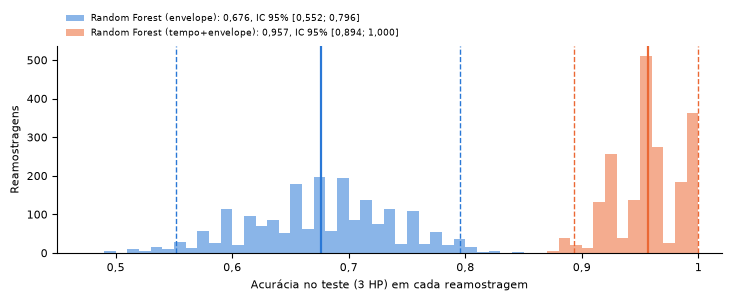

In [58]:
def figura_bootstrap(te: pd.DataFrame) -> None:
    """Distribuição bootstrap (2000 reamostragens de gravações inteiras,
    estratificadas por classe) da acurácia no teste dos dois Random Forest,
    com a estimativa pontual e o intervalo de 95% por percentis."""
    plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False})
    fig, ax = plt.subplots(figsize=(7.2, 2.9), constrained_layout=True)
    for col, nome, cor in (("ok_env", "Random Forest (envelope)", "#2a78d6"),
                           ("ok_rf", "Random Forest (tempo+envelope)", "#eb6834")):
        inf, sup, v = bootstrap_por_gravacao(te, lambda d, c=col: d[c].mean(), devolver_valores=True)
        ax.hist(v, bins=np.linspace(0.4, 1.0, 61), color=cor, alpha=0.55,
                label=f"{nome}: {te[col].mean():.3f}, IC 95% [{inf:.3f}; {sup:.3f}]".replace(".", ","))
        for lim in (inf, sup):
            ax.axvline(lim, color=cor, lw=1.0, ls="--")
        ax.axvline(te[col].mean(), color=cor, lw=1.6)
    ax.set_xlabel("Acurácia no teste (3 HP) em cada reamostragem")
    ax.set_ylabel("Reamostragens")
    ax.xaxis.set_major_formatter(VIRGULA)
    ax.set_xlim(0.45, 1.02)
    ax.legend(fontsize=6.5, frameon=False, loc="lower left", bbox_to_anchor=(0, 1.0), ncols=1)
    fig.savefig(DIR_FIGURES / "bootstrap_acuracia.png", dpi=200)


with plt.rc_context():  # não altera a fonte das figuras seguintes
    figura_bootstrap(te)

### Montagem nova: diferente do acaso?

Com um diâmetro de fora, cada combinação de classe e diâmetro é uma montagem
(9 no total, 4 gravações cada). Uma montagem conta como acertada quando a maioria
das suas janelas recebe a classe correta. Teste binomial unilateral contra o
acaso (1/3), na montagem e na gravação (esta última ignora a dependência entre as
4 gravações de uma montagem, e é dada só como referência).

In [59]:
from sklearn.model_selection import cross_val_predict

falhas_m = (meta["classe"] != "normal").to_numpy()
dm = meta.loc[falhas_m, ["registro", "classe", "diametro_pol"]].reset_index(drop=True)
dm["montagem"] = dm["classe"] + " " + dm["diametro_pol"]
y_m, g_m = dm["classe"].to_numpy(), dm["diametro_pol"].to_numpy()
preditores = {
    "Random Forest (tempo+envelope)": cross_val_predict(
        modelos_candidatos()["Random Forest"], F.loc[falhas_m, cols], y_m, groups=g_m, cv=LeaveOneGroupOut(), n_jobs=-1),
    "KNN k=9 (tempo+envelope)": cross_val_predict(
        modelos_candidatos()["KNN (k=9)"], F.loc[falhas_m, cols], y_m, groups=g_m, cv=LeaveOneGroupOut(), n_jobs=-1),
    "Regra física (sem treino)": prever_regra_fisica(F.loc[falhas_m]).to_numpy(),
}
linhas = []
for nome, p in preditores.items():
    dm["ok"] = p == y_m
    por_mont = dm.groupby("montagem")["ok"].mean() > 0.5
    por_grav = dm.groupby("registro")["ok"].mean() > 0.5
    ic_acc = bootstrap_por_gravacao(dm, lambda d: d["ok"].mean(), estrato="classe", unidade="montagem")
    linhas.append({
        "modelo": nome, "acuracia_janelas": dm["ok"].mean(), "ic95_inf": ic_acc[0], "ic95_sup": ic_acc[1],
        "montagens_certas": int(por_mont.sum()), "montagens": len(por_mont),
        "p_binomial_montagens": binomtest(int(por_mont.sum()), len(por_mont), 1 / 3, alternative="greater").pvalue,
        "gravacoes_certas": int(por_grav.sum()), "gravacoes": len(por_grav),
        "p_binomial_gravacoes": binomtest(int(por_grav.sum()), len(por_grav), 1 / 3, alternative="greater").pvalue,
    })
montagem_inf = pd.DataFrame(linhas)

# Diferença regra física − Random Forest, com bootstrap por montagem (pareado).
dm["ok_regra"] = preditores["Regra física (sem treino)"] == y_m
dm["ok_rf"] = preditores["Random Forest (tempo+envelope)"] == y_m
dif = bootstrap_por_gravacao(dm, lambda d: d["ok_regra"].mean() - d["ok_rf"].mean(), estrato="classe", unidade="montagem")
montagem_inf.attrs["dif"] = (dm["ok_regra"].mean() - dm["ok_rf"].mean(), *dif)
pd.DataFrame([{"diferenca_regra_menos_rf": montagem_inf.attrs["dif"][0], "ic95_inf": dif[0], "ic95_sup": dif[1]}]).to_csv(
    DIR_METRICS / "inferencia_montagem_diferenca.csv", index=False, float_format="%.4f")
montagem_inf.to_csv(DIR_METRICS / "inferencia_montagem.csv", index=False, float_format="%.4g")
print("Diferença (regra física − Random Forest): %.3f, IC95%% [%.3f; %.3f]" % montagem_inf.attrs["dif"])
montagem_inf.round(4)

Diferença (regra física − Random Forest): 0.201, IC95% [0.036; 0.380]


,modelo,acuracia_janelas,ic95_inf,ic95_sup,montagens_certas,montagens,p_binomial_montagens,gravacoes_certas,gravacoes,p_binomial_gravacoes
0,Random Forest (tempo+envelope),0.4567,0.3073,0.6215,4,9,0.3497,17,36,0.0584
1,KNN k=9 (tempo+envelope),0.5381,0.2352,0.8296,5,9,0.1448,20,36,0.0050
2,Regra física (sem treino),0.6573,0.5034,0.8071,6,9,0.0424,24,36,0.0000


### Variabilidade entre sementes

Os resultados acima usam `SEED = 42`. Retreinamos os dois Random Forest
(tempo+envelope e só envelope, com os hiperparâmetros da busca) com 10 sementes
(0–9) e a CNN 1D (janelas normalizadas) com 5 (0–4), todas além da semente 42
usada no resto do notebook.

In [60]:
linhas = []
params_rf = {k.replace("clf__", ""): v for k, v in buscas["Random Forest"].best_params_.items()}
for s in range(10):
    m = pipeline(RandomForestClassifier(class_weight="balanced", random_state=s, n_jobs=-1, **params_rf))
    m.fit(x_tr, y_tr)
    linhas.append({"modelo": "Random Forest (tempo+envelope)", "semente": s,
                   "acuracia_teste": (m.predict(F.loc[teste, cols]) == y_te).mean(),
                   "generalizacao_OR": (m.predict(Fg[cols]) == "OR").mean()})
params_env = {k.replace("clf__", ""): v for k, v in
              ajustar_hiperparametros("Random Forest", F.loc[treino, cols_env], y_tr, g_tr).best_params_.items()}
for s in range(10):
    m = pipeline(RandomForestClassifier(class_weight="balanced", random_state=s, n_jobs=-1, **params_env))
    m.fit(F.loc[treino, cols_env], y_tr)
    linhas.append({"modelo": "Random Forest (envelope)", "semente": s,
                   "acuracia_teste": (m.predict(F.loc[teste, cols_env]) == y_te).mean(),
                   "generalizacao_OR": (m.predict(Fg[cols_env]) == "OR").mean()})
try:
    for s in range(5):
        c = ClassificadorCNN("normalizado", seed=s).fit(X[treino], meta.loc[treino, "classe"])
        linhas.append({"modelo": "CNN 1D (normalizado)", "semente": s,
                       "acuracia_teste": (c.predict(X[teste]) == y_te.to_numpy()).mean(),
                       "generalizacao_OR": (c.predict(Xg) == "OR").mean()})
except ImportError:
    print("PyTorch não instalado: CNN ignorada.")
sementes = pd.DataFrame(linhas)
sementes.to_csv(DIR_METRICS / "sementes.csv", index=False, float_format="%.4f")
sementes.groupby("modelo")[["acuracia_teste", "generalizacao_OR"]].agg(["mean", "std", "min", "max"]).round(3)

acuracia_teste                      generalizacao_OR                     
                                         mean    std    min    max             mean    std    min    max
modelo                                                                                                  
CNN 1D (normalizado)                    0.998  0.004  0.991  1.000            0.552  0.066  0.439  0.603
Random Forest (envelope)                0.679  0.003  0.673  0.682            0.759  0.002  0.755  0.762
Random Forest (tempo+envelope)          0.958  0.004  0.950  0.962            0.481  0.094  0.395  0.719

# **Predição**

5. **Aplique o modelo final a casos novos.** Os "casos novos" são as gravações de
pista externa com o defeito a 3 h e a 12 h — posições que o modelo nunca viu. A
resposta correta é sempre "OR".

In [61]:
pred_g = model.predict(Fg[cols])
print(f"Random Forest (tempo+envelope): {(pred_g == 'OR').mean():.1%} classificadas como OR")
print(f"Regra física (sem treino):      {(prever_regra_fisica(Fg) == 'OR').mean():.1%} classificadas como OR")
pd.crosstab([meta_g["posicao_or_h"].rename("posição"), meta_g["diametro_pol"].rename("diâmetro")],
            pd.Series(pred_g, name="predita"))

Random Forest (tempo+envelope): 40.0% classificadas como OR
Regra física (sem treino):      99.8% classificadas como OR


predita             B   IR   OR
posição diâmetro               
12      0.007       2  228    2
        0.021     109    0  123
3       0.007       0    0  232
        0.021      11  207   14

In [62]:
cols_env = CONJUNTOS_FEATURES["envelope"]
modelo_env = ajustar_hiperparametros("Random Forest", F.loc[treino, cols_env], y_tr, g_tr).best_estimator_
print(f"Só envelope — teste: {accuracy_score(y_te, modelo_env.predict(F.loc[teste, cols_env])):.1%} | "
      f"generalização (OR): {(modelo_env.predict(Fg[cols_env]) == 'OR').mean():.1%}")

Só envelope — teste: 67.6% | generalização (OR): 76.0%


O modelo só com envelope acerta menos no teste, mas **generaliza melhor** para o
defeito em outra posição: usa a frequência do defeito, não a amplitude da montagem.

# **Verificações**

Checagens automáticas das hipóteses de que os resultados dependem. Se alguma
falhar, o notebook para aqui.

In [63]:
# 1. Frequências características batem com a documentação do CWRU (múltiplos de f_r).
f1 = frequencias_caracteristicas(60.0)
assert abs(f1.bpfi - 5.4152) < 1e-3 and abs(f1.bpfo - 3.5848) < 1e-3 and abs(f1.bsf_2x - 4.7135) < 1e-3

# 2. Normais decimados: a linha de 120 Hz (2 x rede elétrica) continua em 120 Hz.
for rid in (97, 98, 99, 100):
    x = carregar_sinal(manifesto[manifesto["id"] == rid].iloc[0])
    esp = np.abs(np.fft.rfft(x * np.hanning(len(x))))
    fr_ = np.fft.rfftfreq(len(x), 1 / FS_HZ)
    faixa = (fr_ > 110) & (fr_ < 130)
    assert abs(fr_[faixa][np.argmax(esp[faixa])] - 120.0) < 0.5, rid

# 3. Nenhuma gravação em treino e teste ao mesmo tempo.
assert set(meta.loc[treino, "registro"]).isdisjoint(meta.loc[teste, "registro"])

# 4. O detector one-class recusa janelas de falha no treino.
try:
    treinar_detector("mahalanobis", F.head(20), ["IR"] * 20, NOMES_FEATURES)
    raise AssertionError("o detector aceitou janela de falha")
except ValueError:
    pass

# 6. Validação cruzada por carga e por diâmetro: nenhuma gravação em dois lados de um fold.
for grupos, mascara in ((meta.loc[treino, "carga_hp"], treino), (meta.loc[falhas_m, "diametro_pol"], falhas_m)):
    regs = meta.loc[mascara, "registro"].to_numpy()
    for i_tr, i_va in LeaveOneGroupOut().split(regs, groups=grupos):
        assert set(regs[i_tr]).isdisjoint(regs[i_va])

# 7. Nada do teste (3 HP) entra no ajuste: GridSearch, scaler e limiares usam só o treino.
assert len(x_tr) == treino.sum() and set(meta.loc[treino, "carga_hp"]) == {0, 1, 2}

# 5. Janela = 4096 amostras e cobre 3 períodos da gaiola na menor rotação.
assert tamanho_janela(manifesto["rpm"].min()) == 4096

print("Todas as verificações passaram.")

Todas as verificações passaram.


# **Resumo**

| Tarefa | Resultado no teste (3 HP) | Com montagem nova |
|---|---|---|
| Detectar (Mahalanobis, tempo+envelope) | TPR 1,00 · FPR 0,12 — mas o RMS sozinho dá AUC 1,00 | — |
| Detectar, recomendado (Autoencoder, envelope) | TPR 0,54 · FPR 0,03 · alarma 67% (Y), 2% (P), 42% (N) | — |
| Diagnosticar (Random Forest) | 95,7% · esfera com recall 0,99 e precisão 0,88 | 45,7% |
| Diagnosticar (CNN 1D) | 99,7% | 49,8% |
| Regra física (sem treino) | IR 1,00 · B 0,22 · OR 0,71 | **65,7%** (6/9 montagens, p = 0,042); reconhece 99,8% da pista externa em outra posição |

A detecção é resolvida pela amplitude; o diagnóstico aprendido não se mantém numa montagem
nova. A física generaliza onde o aprendizado não generaliza — e um modelo treinado
só com envelope também generaliza quando a classe sem assinatura (esfera) sai do
problema (análise exploratória). O detector
recomendado foi escolhido olhando o teste, então sua FPR é uma estimativa
otimista. Discussão completa no relatório.